### Calculate the Occupied, Unoccupied, and Active Space for LiPF6

In [48]:
from pyscf import gto, scf
import numpy as np

# ──────────────────────────────────────────────────────────────
# 1. Define the LiPF6 molecule (neutral Li+ · PF6– pair)
#    - P–F bond length ≈ 1.57 Å (ideal octahedron)
#    - Li+ placed 3 Å from P along +x for simplicity
# ──────────────────────────────────────────────────────────────
mol = gto.Mole()
mol.atom = '''
P        -0.000000        0.000000        0.207689
F         0.000000        1.159716       -1.114057
F        -0.000000       -1.187351        1.269191
F        -1.609678        0.000000        0.083000
F         1.609678       -0.000000        0.083000
F        -0.000000       -1.159716       -1.114057
F         0.000000        1.187351        1.269191
Li        0.000000        0.000000       -2.467253
'''
mol.basis  = '631g'         # minimal basis for quick tests
mol.charge = 0                # Li+ + PF6– → neutral overall
mol.spin   = 0                # closed‑shell RHF
mol.build()

# ──────────────────────────────────────────────────────────────
# 2. Hartree–Fock calculation
# ──────────────────────────────────────────────────────────────
mf = scf.RHF(mol)
mf.kernel()

# ──────────────────────────────────────────────────────────────
# 3. Orbital energies and occupation analysis
# ──────────────────────────────────────────────────────────────
mo_energies  = mf.mo_energy
n_electrons  = mol.nelectron

print("\n📊  Orbital Energies (LiPF₆):")
for i, e in enumerate(mo_energies):
    occ = "occupied" if i < n_electrons // 2 else "virtual"
    print(f"  Orbital {i:2d} : {e: .6f} Ha   →  {occ}")

# ──────────────────────────────────────────────────────────────
# 4. Simple active‑space suggestions
#    • Freeze very low‑lying core orbitals (e < −0.8 Ha)
#    • Remove high virtuals            (e >  +0.5 Ha)
#    Adjust thresholds to taste!
# ──────────────────────────────────────────────────────────────
core_threshold    = -0.7
virtual_threshold =  0.5

frozen  = [i for i, e in enumerate(mo_energies) if e < core_threshold]
removed = [i for i, e in enumerate(mo_energies) if e > virtual_threshold]

print("\nSuggested core orbitals to freeze :", frozen)
print("Suggested high virtuals to remove :", removed)
print("Active orbitals (keep the rest!)")


converged SCF energy = -944.752148720955

📊  Orbital Energies (LiPF₆):
  Orbital  0 : -80.348517 Ha   →  occupied
  Orbital  1 : -26.340786 Ha   →  occupied
  Orbital  2 : -26.340779 Ha   →  occupied
  Orbital  3 : -26.328304 Ha   →  occupied
  Orbital  4 : -26.328290 Ha   →  occupied
  Orbital  5 : -26.326768 Ha   →  occupied
  Orbital  6 : -26.326766 Ha   →  occupied
  Orbital  7 : -7.866249 Ha   →  occupied
  Orbital  8 : -5.764374 Ha   →  occupied
  Orbital  9 : -5.764309 Ha   →  occupied
  Orbital 10 : -5.763730 Ha   →  occupied
  Orbital 11 : -2.535560 Ha   →  occupied
  Orbital 12 : -1.732426 Ha   →  occupied
  Orbital 13 : -1.647775 Ha   →  occupied
  Orbital 14 : -1.647387 Ha   →  occupied
  Orbital 15 : -1.642729 Ha   →  occupied
  Orbital 16 : -1.608464 Ha   →  occupied
  Orbital 17 : -1.604414 Ha   →  occupied
  Orbital 18 : -0.967855 Ha   →  occupied
  Orbital 19 : -0.827969 Ha   →  occupied
  Orbital 20 : -0.826416 Ha   →  occupied
  Orbital 21 : -0.817226 Ha   →  occupie

In [ ]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit.primitives import Estimator


# Step 1: Geometry for LiPF6
lipf6_geometry = (
    "P 0.0000 0.0000 0.2077; "
    "F 0.0000 1.1597 -1.1141; "
    "F 0.0000 -1.1874 1.2692; "
    "F -1.6097 0.0000 0.0830; "
    "F 1.6097 0.0000 0.0830; "
    "F 0.0000 -1.1597 -1.1141; "
    "F 0.0000 1.1874 1.2692; "
    "Li 0.0000 0.0000 -2.4673"
)


# === Step 1: Define the N2 molecule ===
driver = PySCFDriver(
    atom= lipf6_geometry,
    basis="631g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM
)
es_problem = driver.run()

# === Step 2: Freeze core + remove high-energy virtuals ===
freeze_transformer = FreezeCoreTransformer(
    freeze_core=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33],   # Core
    remove_orbitals=[38, 39, 40, 41, 42, 43]            # Virtual
)
es_problem_reduced = freeze_transformer.transform(es_problem)

# === Step 3: Reduce active space (adjust electrons/orbitals as needed) ===
active_transformer = ActiveSpaceTransformer(
    num_electrons=4,
    num_spatial_orbitals=4          # 3 orbitals × 2 = 6 qubits
)
es_problem_active = active_transformer.transform(es_problem_reduced)

# === Step 4: Build qubit Hamiltonian ===
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(es_problem_active.second_q_ops()[0])
num_particles = es_problem_active.num_particles
num_spatial_orbitals = es_problem_active.num_spatial_orbitals

# === Step 5: Ansatz and initial state ===
init_state = HartreeFock(num_spatial_orbitals, num_particles, mapper)
ansatz = UCCSD(num_spatial_orbitals, num_particles, mapper, initial_state=init_state)
#ansatz = EfficientSU2(qubit_hamiltonian.num_qubits)

# === Step 6: VQE setup ===
optimizer = SLSQP(maxiter=1000)
estimator = Estimator()

vqe_solver = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

solver = GroundStateEigensolver(mapper, vqe_solver)
result = solver.solve(es_problem_active)

# === Step 7: Output results ===
print("\n Molecule: LiPF6 (active space)")
print(" Qubits used:", qubit_hamiltonian.num_qubits)
print("Particles:", num_particles)
print("Spatial Orbitals:", num_spatial_orbitals)
print("Ground state energy (Hartree):", result.total_energies[0].real)
print("Optimal parameters:", result.raw_result.optimal_point)

# Optional: visualize ansatz
#ansatz.assign_parameters(result.raw_result.optimal_point).decompose(reps=3).draw("mpl", style="iqp")


 Molecule: LiPF6 (active space)
 Qubits used: 8
Particles: (2, 2)
Spatial Orbitals: 4
Ground state energy (Hartree): -944.7521624537657
Optimal parameters: [-2.68009322e-07 -3.29857627e-07 -7.83411865e-07 -4.74170339e-07
 -4.53554238e-07  4.12322034e-08 -1.64928814e-07 -1.85544915e-07
  2.06161017e-08 -1.17738557e-04  2.06161017e-08  0.00000000e+00
  0.00000000e+00  2.06161017e-08 -7.37705968e-04  0.00000000e+00
  0.00000000e+00  2.06161017e-08  2.06161017e-08 -6.54767390e-05
  0.00000000e+00  2.06161017e-08  2.06161017e-08  0.00000000e+00
 -4.85467963e-04  0.00000000e+00]


In [59]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA
from qiskit.primitives import Estimator


# Step 1: Geometry for LiPF6
lipf6_geometry = (
    "P 0.0000 0.0000 0.2077; "
    "F 0.0000 1.1597 -1.1141; "
    "F 0.0000 -1.1874 1.2692; "
    "F -1.6097 0.0000 0.0830; "
    "F 1.6097 0.0000 0.0830; "
    "F 0.0000 -1.1597 -1.1141; "
    "F 0.0000 1.1874 1.2692; "
    "Li 0.0000 0.0000 -2.4673"
)


# === Step 1: Define the N2 molecule ===
driver = PySCFDriver(
    atom= lipf6_geometry,
    basis="631g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM
)
es_problem = driver.run()

print("Spatial orbitals :", es_problem.num_spatial_orbitals)
print("Spin Orbitals", es_problem.num_spin_orbitals)
# How many physical electrons (α + β)?
n_alpha, n_beta = es_problem.num_particles
print("Electrons        :", n_alpha + n_beta, f"({n_alpha} α, {n_beta} β)")
no_of_qubit = 2*es_problem.num_spatial_orbitals
print("Number Qubit needed :", no_of_qubit)

# === Step 2: Freeze core + remove high-energy virtuals ===
freeze_transformer = FreezeCoreTransformer(
    freeze_core=list(range(0, 33)),   # Core
    remove_orbitals=list(range(37, es_problem.num_spatial_orbitals))            # Virtual
)
es_problem_reduced = freeze_transformer.transform(es_problem)

# === Step 3: Reduce active space (adjust electrons/orbitals as needed) ===
active_transformer = ActiveSpaceTransformer(
    num_electrons=6,
    num_spatial_orbitals=4          # 3 orbitals × 2 = 6 qubits
)
es_problem_active = active_transformer.transform(es_problem_reduced)

# === Step 4: Build qubit Hamiltonian ===
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(es_problem_active.second_q_ops()[0])
num_particles = es_problem_active.num_particles
num_spatial_orbitals = es_problem_active.num_spatial_orbitals

# === Step 5: Ansatz and initial state ===
init_state = HartreeFock(num_spatial_orbitals, num_particles, mapper)
ansatz = UCCSD(num_spatial_orbitals, num_particles, mapper, initial_state=init_state)
#ansatz = EfficientSU2(qubit_hamiltonian.num_qubits)

# === Step 6: VQE setup ===
#optimizer = SLSQP(maxiter=1000)
optimizer = COBYLA(maxiter=10000)
estimator = Estimator()

vqe_solver = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

solver = GroundStateEigensolver(mapper, vqe_solver)
result = solver.solve(es_problem_active)

# === Step 7: Output results ===
print("\n Molecule: LiPF6 (active space)")
print(" Qubits used:", qubit_hamiltonian.num_qubits)
print("Particles:", num_particles)
print("Spatial Orbitals:", num_spatial_orbitals)
print("Ground state energy (Hartree):", result.total_energies[0].real)
print("Optimal parameters:", result.raw_result.optimal_point)

# Optional: visualize ansatz
#ansatz.assign_parameters(result.raw_result.optimal_point).decompose(reps=3).draw("mpl", style="iqp")

Spatial orbitals : 76
Spin Orbitals 152
Electrons        : 72 (36 α, 36 β)
Number Qubit needed : 152

 Molecule: LiPF6 (active space)
 Qubits used: 8
Particles: (3, 3)
Spatial Orbitals: 4
Ground state energy (Hartree): -944.75216154261
Optimal parameters: [ 4.74842403e-05 -1.43767351e-05  9.51130417e-06  4.12567869e-05
 -6.30200807e-05 -2.37644547e-05 -4.03959572e-04  2.73652784e-05
 -1.17071725e-05  1.08970479e-05 -1.15864492e-04 -3.09534290e-06
  2.50177229e-05 -1.87310007e-06 -5.37461723e-05]


In [32]:
from pyscf import gto, scf, mp, cc, mcscf
import numpy as np

# ──────────────────────────────────────────────────────────────
# 1.  Geometry (your optimized LiPF6)
# ──────────────────────────────────────────────────────────────
mol = gto.Mole()
mol.atom = '''
P        -0.000000        0.000000        0.207689
F         0.000000        1.159716       -1.114057
F        -0.000000       -1.187351        1.269191
F        -1.609678        0.000000        0.083000
F         1.609678       -0.000000        0.083000
F        -0.000000       -1.159716       -1.114057
F         0.000000        1.187351        1.269191
Li        0.000000        0.000000       -2.467253
'''
mol.basis  = "sto-3g"
mol.charge = 0
mol.spin   = 0          # closed shell
mol.build()

# ──────────────────────────────────────────────────────────────
# 2.  RHF
# ──────────────────────────────────────────────────────────────
mf = scf.RHF(mol).run()
hf_e = mf.e_tot

# ──────────────────────────────────────────────────────────────
# 3.  MP2
# ──────────────────────────────────────────────────────────────
mp2     = mp.MP2(mf).run()
mp2_e   = mp2.e_tot

# ──────────────────────────────────────────────────────────────
# 4.  CCSD
# ──────────────────────────────────────────────────────────────
ccsd    = cc.CCSD(mf).run()
ccsd_e  = ccsd.e_tot

# ──────────────────────────────────────────────────────────────
# 5.  Define an active space for affordable FCI
#     • Freeze spatial orbitals 0 … 31  (deep core)
#     • Keep 32 … 37 as the active six orbitals (8 e⁻)
#     • Discard 38 … end   (very high virtuals)
# ──────────────────────────────────────────────────────────────
ncore      = 32                     # frozen pairs
ncas       = 6                      # active spatial orbitals
nelecas    = 8                      # 4 α + 4 β  (still closed shell)

casci = mcscf.CASCI(mf, ncas, nelecas)
casci.ncore = ncore
casci.fcisolver.nroots = 1          # ground state only
#casci_e, _ = casci.kernel()
casci_e, *_ = casci.kernel()

# ──────────────────────────────────────────────────────────────
# 6.  Print summary
# ──────────────────────────────────────────────────────────────
print("\n=== Energies (Ha) with STO‑3G ===")
print(f"  RHF   : {hf_e: .8f}")
print(f"  MP2   : {mp2_e: .8f}")
print(f"  CCSD  : {ccsd_e: .8f}")
print(f"  CASCI : {casci_e: .8f}   (FCI in 8 e⁻/6 orb active space)")

print("\nBasis  functions       :", mf.mo_coeff.shape[1])
print("Spatial orbitals kept  :", ncas, f"(active)\n"
      "                        +", ncore, "(frozen)")
print("Electrons              :", mol.nelectron,
      f"→ {nelecas} in active space")

# 7.  When you have VQE:
vqe_energy = result.total_energies[0].real   # from your Qiskit workflow
print(f"  VQE   : {vqe_energy: .8f}")

converged SCF energy = -932.490555993609
E(MP2) = -932.644936964897  E_corr = -0.154380971287722
E(SCS-MP2) = -932.649444663577  E_corr = -0.158888669967657
E(CCSD) = -932.6681741598532  E_corr = -0.1776181662441066
CASCI E = -932.490575442346  E(CI) = -12.6536321811838  S^2 = 0.0000000

=== Energies (Ha) with STO‑3G ===
  RHF   : -932.49055599
  MP2   : -932.64493696
  CCSD  : -932.66817416
  CASCI : -932.49057544   (FCI in 8 e⁻/6 orb active space)

Basis  functions       : 44
Spatial orbitals kept  : 6 (active)
                        + 32 (frozen)
Electrons              : 72 → 8 in active space
  VQE   : -932.49056412


Running VQE at Li–F distance 1.50 Å ...
Running VQE at Li–F distance 1.75 Å ...
Running VQE at Li–F distance 2.00 Å ...
Running VQE at Li–F distance 2.25 Å ...
Running VQE at Li–F distance 2.50 Å ...
Running VQE at Li–F distance 2.75 Å ...
Running VQE at Li–F distance 3.00 Å ...
Running VQE at Li–F distance 3.25 Å ...
Running VQE at Li–F distance 3.50 Å ...
Running VQE at Li–F distance 3.75 Å ...
Running VQE at Li–F distance 4.00 Å ...
Running VQE at Li–F distance 4.25 Å ...
Running VQE at Li–F distance 4.50 Å ...
Running VQE at Li–F distance 4.75 Å ...
Running VQE at Li–F distance 5.00 Å ...


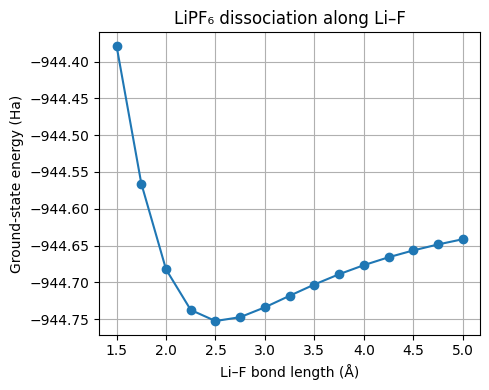

In [53]:
###############################################################
# Li–F dissociation curve with VQE (active‑space UCCSD)
###############################################################
import numpy as np
import matplotlib.pyplot as plt

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# ---------------- USER SETTINGS -----------------
basis                 = "6-31g"
freeze_core_list      = list(range(0, 33))
virtual_trim_start    = 38
active_nelec          = 6
active_norb           = 4
optimizer_maxiter     = 10000          # keep modest so sweep finishes
distances             = np.linspace(1.5, 5.0, 15)   # Å, Li–nearest‑F distance
# ------------------------------------------------

def make_geometry(d):
    """Return LiPF6 geometry string with Li along –z at distance d from P."""
    return (
        f"P 0.0000 0.0000 0.2077; "
        f"F 0.0000 1.1597 -1.1141; "
        f"F 0.0000 -1.1874 1.2692; "
        f"F -1.6097 0.0000 0.0830; "
        f"F 1.6097 0.0000 0.0830; "
        f"F 0.0000 -1.1597 -1.1141; "
        f"F 0.0000 1.1874 1.2692; "
        f"Li 0.0000 0.0000 {-d:6.4f}"
    )

def vqe_energy(geom):
    """Return VQE ground‑state energy for a given geometry."""
    driver = PySCFDriver(atom=geom, basis=basis, unit=DistanceUnit.ANGSTROM)
    prob   = driver.run()

    # freeze core + trim virtuals
    freeze = FreezeCoreTransformer(
        freeze_core=freeze_core_list,
        remove_orbitals=list(range(virtual_trim_start, prob.num_spatial_orbitals))
    )
    prob = freeze.transform(prob)

    # active space
    active = ActiveSpaceTransformer(num_electrons=active_nelec,
                                    num_spatial_orbitals=active_norb)
    prob = active.transform(prob)

    mapper = JordanWignerMapper()
    qubit_op = mapper.map(prob.second_q_ops()[0])

    init = HartreeFock(active_norb, prob.num_particles, mapper)
    ans  = UCCSD(active_norb, prob.num_particles, mapper, initial_state=init)

    vqe = VQE(Estimator(), ansatz=ans,
              optimizer=COBYLA(maxiter=optimizer_maxiter),
              initial_point=[0.0] * ans.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)
    res    = solver.solve(prob)
    return res.total_energies[0].real

# ---------- sweep distances ----------
energies = []
for d in distances:
    print(f"Running VQE at Li–F distance {d:4.2f} Å ...")
    energies.append(vqe_energy(make_geometry(d)))

# ---------- plot ----------
plt.figure(figsize=(5,4))
plt.plot(distances, energies, "-o")
plt.xlabel("Li–F bond length (Å)")
plt.ylabel("Ground‑state energy (Ha)")
plt.title("LiPF₆ dissociation along Li–F")
plt.grid(True)
plt.tight_layout()
plt.savefig("LiPF6_dissociation_cuve.png", dpi=300)
plt.show()

In [61]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_nature.second_q.algorithms import QEOM, EvaluationRule
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# === Step 1: Molecule Geometry ===
lipf6_geometry = (
    "P 0.0000 0.0000 0.2077; "
    "F 0.0000 1.1597 -1.1141; "
    "F 0.0000 -1.1874 1.2692; "
    "F -1.6097 0.0000 0.0830; "
    "F 1.6097 0.0000 0.0830; "
    "F 0.0000 -1.1597 -1.1141; "
    "F 0.0000 1.1874 1.2692; "
    "Li 0.0000 0.0000 -2.4673"
)

driver = PySCFDriver(
    atom=lipf6_geometry,
    basis="631g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM
)
es_problem = driver.run()

# === Step 2: Freeze core + reduce orbitals ===
freeze_transformer = FreezeCoreTransformer(
    freeze_core=list(range(0, 33)),
    remove_orbitals=list(range(37, es_problem.num_spatial_orbitals))
)
es_problem_reduced = freeze_transformer.transform(es_problem)

# === Step 3: Active space ===
active_transformer = ActiveSpaceTransformer(num_electrons=6, num_spatial_orbitals=4)
es_problem_active = active_transformer.transform(es_problem_reduced)

# === Step 4: Qubit mapping ===
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(es_problem_active.second_q_ops()[0])
num_particles = es_problem_active.num_particles
num_spatial_orbitals = es_problem_active.num_spatial_orbitals

# === Step 5: Ansatz ===
init_state = HartreeFock(num_spatial_orbitals, num_particles, mapper)
ansatz = UCCSD(num_spatial_orbitals, num_particles, mapper, initial_state=init_state)

# === Step 6: VQE Ground State Solver ===
optimizer = COBYLA(maxiter=10000)
estimator = Estimator()
vqe_solver = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

g_solver = GroundStateEigensolver(mapper, vqe_solver)

# === Step 7: Excited State Solver using qEOM ===
qeom_solver = QEOM(g_solver, estimator, "s", EvaluationRule.ALL)  # Use both single and double excitations
result = qeom_solver.solve(es_problem_active)

# === Step 8: Print Results ===
print("\n=== LiPF6 Excited State Energies ===")
energies = [res.real for res in result.total_energies]
ground_state_energy = energies[0]

for i, energy in enumerate(energies):
    label = "Ground" if i == 0 else f"Excited {i}"
    delta_E = energy - ground_state_energy if i > 0 else 0
    print(f"{label} State Energy: {energy:.6f} Hartree", end="")
    if i > 0:
        print(f"   ΔE = {delta_E:.6f} Hartree ≈ {delta_E*27.2114:.2f} eV")
    else:
        print()


=== LiPF6 Excited State Energies ===
Ground State Energy: -944.752162 Hartree
Excited 1 State Energy: -944.244386 Hartree   ΔE = 0.507775 Hartree ≈ 13.82 eV
Excited 2 State Energy: -944.244197 Hartree   ΔE = 0.507965 Hartree ≈ 13.82 eV
Excited 3 State Energy: -944.243781 Hartree   ΔE = 0.508380 Hartree ≈ 13.83 eV
Excited 4 State Energy: -944.243441 Hartree   ΔE = 0.508721 Hartree ≈ 13.84 eV
Excited 5 State Energy: -944.242481 Hartree   ΔE = 0.509681 Hartree ≈ 13.87 eV
Excited 6 State Energy: -944.241373 Hartree   ΔE = 0.510788 Hartree ≈ 13.90 eV


In [35]:
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM, ExcitedStatesEigensolver
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.units import DistanceUnit
from qiskit_algorithms import NumPyEigensolver, VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit.primitives import Estimator
from qiskit_nature.second_q.algorithms import EvaluationRule

# === Step 1: Geometry and driver ===
lipf6_geometry = (
    "P 0.0000 0.0000 0.2077; "
    "F 0.0000 1.1597 -1.1141; "
    "F 0.0000 -1.1874 1.2692; "
    "F -1.6097 0.0000 0.0830; "
    "F 1.6097 0.0000 0.0830; "
    "F 0.0000 -1.1597 -1.1141; "
    "F 0.0000 1.1874 1.2692; "
    "Li 0.0000 0.0000 -2.4673"
)

driver = PySCFDriver(atom=lipf6_geometry, basis="631g", charge=0, spin=0, unit=DistanceUnit.ANGSTROM)
es_problem = driver.run()

# === Step 2: Transform for active space ===
es_problem_reduced = FreezeCoreTransformer(
    freeze_core=list(range(0, 33)),
    remove_orbitals=list(range(37, es_problem.num_spatial_orbitals))
).transform(es_problem)

es_problem_active = ActiveSpaceTransformer(
    num_electrons=6,
    num_spatial_orbitals=4
).transform(es_problem_reduced)

mapper = JordanWignerMapper()

# === Step 3: Classical exact eigensolver ===
numpy_solver = NumPyEigensolver(k=4)
numpy_excited_solver = ExcitedStatesEigensolver(mapper, numpy_solver)
numpy_results = numpy_excited_solver.solve(es_problem_active)

# === Step 4: VQE + QEOM ===
estimator = Estimator()
ansatz = UCCSD(
    es_problem_active.num_spatial_orbitals,
    es_problem_active.num_particles,
    mapper,
    initial_state=HartreeFock(
        es_problem_active.num_spatial_orbitals,
        es_problem_active.num_particles,
        mapper,
    ),
)
vqe_solver = VQE(estimator, ansatz, SLSQP())
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

gse = GroundStateEigensolver(mapper, vqe_solver)
qeom_solver = QEOM(gse, estimator, "sd", EvaluationRule.ALL)
qeom_results = qeom_solver.solve(es_problem_active)

# === Step 5: Compare Results ===
print("\n=== NumPy (Exact) Excited State Energies of LiPF6 ===")
for i, e in enumerate(numpy_results.total_energies):
    print(f"State {i}: {e.real:.6f} Hartree")

print("\n=== VQE + qEOM Excited State Energies of LiPF6 ===")
gs_energy = qeom_results.total_energies[0].real
for i, e in enumerate(qeom_results.total_energies):
    label = "Ground" if i == 0 else f"Excited {i}"
    delta_e = e.real - gs_energy if i > 0 else 0
    print(f"{label} State: {e.real:.6f} Hartree", end="")
    if i > 0:
        print(f"   ΔE = {delta_e:.6f} Hartree ≈ {delta_e * 27.2114:.2f} eV")
    else:
        print()

bandgap = qeom_results.computed_energies[1] - qeom_results.computed_energies[0]
print("\n=== HOMO and LUMO gap of LiPF6 ===")
print(f" ΔE_gap = {bandgap:.6f} Hartree ≈ {bandgap * 27.2114:.2f} eV")
#bandgap # in Hartree



=== NumPy (Exact) Excited State Energies of LiPF6 ===
State 0: -944.762408 Hartree
State 1: -944.762408 Hartree
State 2: -944.752162 Hartree
State 3: -944.533103 Hartree

=== VQE + qEOM Excited State Energies of LiPF6 ===
Ground State: -944.752162 Hartree
Excited 1 State: -944.244458 Hartree   ΔE = 0.507703 Hartree ≈ 13.82 eV
Excited 2 State: -944.244278 Hartree   ΔE = 0.507883 Hartree ≈ 13.82 eV
Excited 3 State: -944.243853 Hartree   ΔE = 0.508308 Hartree ≈ 13.83 eV
Excited 4 State: -944.243519 Hartree   ΔE = 0.508643 Hartree ≈ 13.84 eV
Excited 5 State: -944.242481 Hartree   ΔE = 0.509681 Hartree ≈ 13.87 eV
Excited 6 State: -944.241611 Hartree   ΔE = 0.510551 Hartree ≈ 13.89 eV
Excited 7 State: -943.449882 Hartree   ΔE = 1.302279 Hartree ≈ 35.44 eV
Excited 8 State: -943.437296 Hartree   ΔE = 1.314866 Hartree ≈ 35.78 eV
Excited 9 State: -943.417071 Hartree   ΔE = 1.335091 Hartree ≈ 36.33 eV
Excited 10 State: -943.417057 Hartree   ΔE = 1.335105 Hartree ≈ 36.33 eV
Excited 11 State: -943

Running VQE at Li–F distance 1.50 Å ...
Running VQE at Li–F distance 1.76 Å ...
Running VQE at Li–F distance 2.03 Å ...
Running VQE at Li–F distance 2.29 Å ...
Running VQE at Li–F distance 2.56 Å ...
Running VQE at Li–F distance 2.82 Å ...
Running VQE at Li–F distance 3.09 Å ...
Running VQE at Li–F distance 3.35 Å ...
Running VQE at Li–F distance 3.62 Å ...
Running VQE at Li–F distance 3.88 Å ...
Running VQE at Li–F distance 4.15 Å ...
Running VQE at Li–F distance 4.41 Å ...
Running VQE at Li–F distance 4.68 Å ...
Running VQE at Li–F distance 4.94 Å ...
Running VQE at Li–F distance 5.21 Å ...
Running VQE at Li–F distance 5.47 Å ...
Running VQE at Li–F distance 5.74 Å ...
Running VQE at Li–F distance 6.00 Å ...

✅ Saved minimum-energy geometry to LiPF6_min.xyz


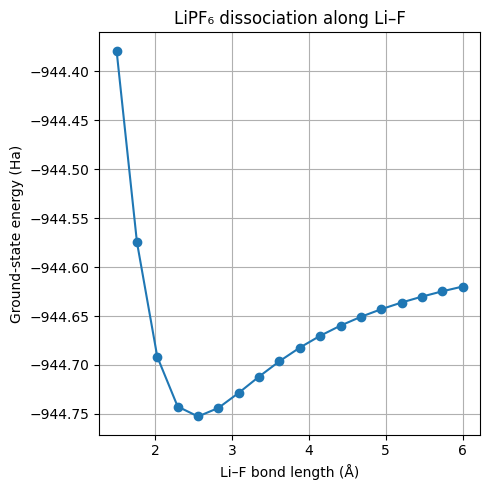

In [65]:
###############################################################
# Na–F dissociation curve with VQE (active‑space UCCSD)
###############################################################
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# ---------------- USER SETTINGS -----------------
basis                 = "6-31g"
freeze_core_list      = list(range(0, 33))
virtual_trim_start    = 37
active_nelec          = 6
active_norb           = 4
optimizer_maxiter     = 10000
distances             = np.linspace(1.5, 6.0, 18)   # 18 points → 1.5 … 6.0 Å
# ------------------------------------------------


def make_geometry(d):
    """Return LiPF6 geometry string with Li along –z at distance d from P."""
    return (
        f"P 0.0000 0.0000 0.2077; "
        f"F 0.0000 1.1597 -1.1141; "
        f"F 0.0000 -1.1874 1.2692; "
        f"F -1.6097 0.0000 0.0830; "
        f"F 1.6097 0.0000 0.0830; "
        f"F 0.0000 -1.1597 -1.1141; "
        f"F 0.0000 1.1874 1.2692; "
        f"Li 0.0000 0.0000 {-d:6.4f}"
    )


def vqe_energy(geom):
    """Return VQE ground‑state energy for a given geometry."""
    driver = PySCFDriver(atom=geom, basis=basis, unit=DistanceUnit.ANGSTROM)
    prob = driver.run()

    # Freeze core and trim virtuals
    freeze = FreezeCoreTransformer(
        freeze_core=freeze_core_list,
        remove_orbitals=list(range(virtual_trim_start, prob.num_spatial_orbitals)),
    )
    prob = freeze.transform(prob)

    # Active space
    active = ActiveSpaceTransformer(
        num_electrons=active_nelec, num_spatial_orbitals=active_norb
    )
    prob = active.transform(prob)

    mapper = JordanWignerMapper()
    qubit_op = mapper.map(prob.second_q_ops()[0])

    init = HartreeFock(active_norb, prob.num_particles, mapper)
    ans = UCCSD(active_norb, prob.num_particles, mapper, initial_state=init)

    vqe = VQE(
        Estimator(),
        ansatz=ans,
        optimizer=COBYLA(maxiter=optimizer_maxiter),
        initial_point=[0.0] * ans.num_parameters,
    )
    solver = GroundStateEigensolver(mapper, vqe)
    res = solver.solve(prob)
    return res.total_energies[0].real


# ---------- sweep distances ----------
energies = []
geometries = []  # keep geom strings for later
for d in distances:
    print(f"Running VQE at Li–F distance {d:4.2f} Å ...")
    geom_str = make_geometry(d)
    geometries.append(geom_str)
    energies.append(vqe_energy(geom_str))

energies = np.array(energies)

# ---------- find minimum and save XYZ ----------
idx_min = np.argmin(energies)
best_d = distances[idx_min]
best_geom = geometries[idx_min]

# Convert geom string → XYZ lines
atoms = [tok.strip() for tok in best_geom.split(";") if tok.strip()]
xyz_lines = [f"{len(atoms)}", f"LiPF6 minimum @ Li–F = {best_d:.2f} Å"]
for line in atoms:
    # split "El x y z" → keep as-is (PySCF-compatible order)
    xyz_lines.append(line.replace("  ", " ").replace(" ;", ""))

xyz_path = Path("LiPF6_min.xyz")
xyz_path.write_text("\n".join(xyz_lines))
print(f"\n✅ Saved minimum-energy geometry to {xyz_path}")

# ---------- plot ----------
plt.figure(figsize=(5, 5))
plt.plot(distances, energies, "-o")
plt.xlabel("Li–F bond length (Å)")
plt.ylabel("Ground‑state energy (Ha)")
plt.title("LiPF₆ dissociation along Li–F")
plt.grid(True)
plt.tight_layout()
plt.savefig("LiPF6_Li-F_dissociation_curve.png", dpi=300)
plt.show()

In [73]:
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM, ExcitedStatesEigensolver
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.units import DistanceUnit
from qiskit_algorithms import NumPyEigensolver, VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit.primitives import Estimator
from qiskit_nature.second_q.algorithms import EvaluationRule

# === Step 1: Geometry and driver ===
lipf6_geometry = (
    "P 0.0000 0.0000 0.2077; "
    "F 0.0000 1.1597 -1.1141; "
    "F 0.0000 -1.1874 1.2692; "
    "F -1.6097 0.0000 0.0830; "
    "F 1.6097 0.0000 0.0830; "
    "F 0.0000 -1.1597 -1.1141; "
    "F 0.0000 1.1874 1.2692; "
    "Li 0.0000 0.0000 -2.4673"
)

driver = PySCFDriver(atom=lipf6_geometry, basis="631g", charge=0, spin=0, unit=DistanceUnit.ANGSTROM)
es_problem = driver.run()

# === Step 2: Transform for active space ===
es_problem_reduced = FreezeCoreTransformer(
    freeze_core=list(range(0, 33)),
    remove_orbitals=list(range(37, es_problem.num_spatial_orbitals))
).transform(es_problem)

es_problem_active = ActiveSpaceTransformer(
    num_electrons=6,
    num_spatial_orbitals=4
).transform(es_problem_reduced)

mapper = JordanWignerMapper()

# === Step 3: Classical exact eigensolver ===
numpy_solver = NumPyEigensolver(k=8)
numpy_excited_solver = ExcitedStatesEigensolver(mapper, numpy_solver)
numpy_results = numpy_excited_solver.solve(es_problem_active)

# === Step 4: VQE + QEOM ===
estimator = Estimator()
ansatz = UCCSD(
    es_problem_active.num_spatial_orbitals,
    es_problem_active.num_particles,
    mapper,
    initial_state=HartreeFock(
        es_problem_active.num_spatial_orbitals,
        es_problem_active.num_particles,
        mapper,
    ),
)
vqe_solver = VQE(estimator, ansatz, SLSQP())
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

gse = GroundStateEigensolver(mapper, vqe_solver)
qeom_solver = QEOM(gse, estimator, "sd", EvaluationRule.ALL)
qeom_results = qeom_solver.solve(es_problem_active)

# === Step 5: Compare Results ===
print("\n=== NumPy (Exact) Excited State Energies of LiPF6 ===")
for i, e in enumerate(numpy_results.total_energies):
    print(f"State {i}: {e.real:.6f} Hartree")

print("\n=== VQE + qEOM Excited State Energies of LiPF6 ===")
gs_energy = qeom_results.total_energies[0].real
for i, e in enumerate(qeom_results.total_energies):
    label = "Ground" if i == 0 else f"Excited {i}"
    delta_e = e.real - gs_energy if i > 0 else 0
    print(f"{label} State: {e.real:.6f} Hartree", end="")
    if i > 0:
        print(f"   ΔE = {delta_e:.6f} Hartree ≈ {delta_e * 27.2114:.2f} eV")
    else:
        print()

bandgap = qeom_results.computed_energies[1] - qeom_results.computed_energies[0]
print("\n=== HOMO and LUMO gap of LiPF6 ===")
print(f" ΔE_gap = {bandgap:.6f} Hartree ≈ {bandgap * 27.2114:.2f} eV")
#bandgap # in Hartree



=== NumPy (Exact) Excited State Energies of LiPF6 ===
State 0: -944.762408 Hartree
State 1: -944.762408 Hartree
State 2: -944.752162 Hartree
State 3: -944.533103 Hartree
State 4: -944.244458 Hartree
State 5: -944.244458 Hartree
State 6: -944.244458 Hartree
State 7: -944.244278 Hartree

=== VQE + qEOM Excited State Energies of LiPF6 ===
Ground State: -944.752162 Hartree
Excited 1 State: -944.244458 Hartree   ΔE = 0.507703 Hartree ≈ 13.82 eV
Excited 2 State: -944.244278 Hartree   ΔE = 0.507883 Hartree ≈ 13.82 eV
Excited 3 State: -944.243853 Hartree   ΔE = 0.508308 Hartree ≈ 13.83 eV
Excited 4 State: -944.243519 Hartree   ΔE = 0.508643 Hartree ≈ 13.84 eV
Excited 5 State: -944.242481 Hartree   ΔE = 0.509681 Hartree ≈ 13.87 eV
Excited 6 State: -944.241611 Hartree   ΔE = 0.510551 Hartree ≈ 13.89 eV
Excited 7 State: -943.449882 Hartree   ΔE = 1.302279 Hartree ≈ 35.44 eV
Excited 8 State: -943.437296 Hartree   ΔE = 1.314866 Hartree ≈ 35.78 eV
Excited 9 State: -943.417071 Hartree   ΔE = 1.33509

In [76]:
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM, ExcitedStatesEigensolver
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.units import DistanceUnit
from qiskit_algorithms import NumPyEigensolver, VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA
from qiskit.primitives import Estimator
from qiskit_nature.second_q.algorithms import EvaluationRule

# === Step 1: Geometry and driver ===
lipf6_geometry = (
    "P 0.0000 0.0000 0.2077; "
    "F 0.0000 1.1597 -1.1141; "
    "F 0.0000 -1.1874 1.2692; "
    "F -1.6097 0.0000 0.0830; "
    "F 1.6097 0.0000 0.0830; "
    "F 0.0000 -1.1597 -1.1141; "
    "F 0.0000 1.1874 1.2692; "
    "Li 0.0000 0.0000 -2.4673"
)

driver = PySCFDriver(atom=lipf6_geometry, basis="631g", charge=0, spin=0, unit=DistanceUnit.ANGSTROM)
es_problem = driver.run()

# === HOMO–LUMO energies from PySCF ===
orbital_energies = es_problem.orbital_energies
num_electrons = sum(es_problem.num_particles)  # total number of electrons
homo_idx = num_electrons // 2 - 1
lumo_idx = homo_idx + 1
homo = orbital_energies[homo_idx]
lumo = orbital_energies[lumo_idx]
gap_hf = lumo - homo

print("\n=== HOMO–LUMO from Hartree–Fock Orbital Energies ===")
print(f"HOMO (Orb {homo_idx:2d}) = {homo:.6f} Ha ≈ {homo * 27.2114:.2f} eV")
print(f"LUMO (Orb {lumo_idx:2d}) = {lumo:.6f} Ha ≈ {lumo * 27.2114:.2f} eV")
print(f"Gap  (LUMO - HOMO)       = {gap_hf:.6f} Ha ≈ {gap_hf * 27.2114:.2f} eV")

# === Step 2: Freeze Core and Active Space ===
es_problem_reduced = FreezeCoreTransformer(
    freeze_core=list(range(0, 33)),
    remove_orbitals=list(range(37, es_problem.num_spatial_orbitals))
).transform(es_problem)

es_problem_active = ActiveSpaceTransformer(
    num_electrons=6,
    num_spatial_orbitals=4
).transform(es_problem_reduced)

mapper = JordanWignerMapper()

# === Step 3: Classical exact eigensolver (NumPy) ===
numpy_solver = NumPyEigensolver(k=4, filter_criterion=es_problem_active.get_default_filter_criterion())
numpy_excited_solver = ExcitedStatesEigensolver(mapper, numpy_solver)
numpy_results = numpy_excited_solver.solve(es_problem_active)

# === Step 4: VQE + QEOM ===
estimator = Estimator()
ansatz = UCCSD(
    es_problem_active.num_spatial_orbitals,
    es_problem_active.num_particles,
    mapper,
    initial_state=HartreeFock(
        es_problem_active.num_spatial_orbitals,
        es_problem_active.num_particles,
        mapper,
    ),
)
vqe_solver = VQE(estimator, ansatz, COBYLA())
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

gse = GroundStateEigensolver(mapper, vqe_solver)
qeom_solver = QEOM(gse, estimator, "sd", EvaluationRule.ALL)
qeom_results = qeom_solver.solve(es_problem_active)

# === Step 5: Print NumPy Energies ===
print("\n=== NumPy (Exact) Excited State Energies of LiPF6 ===")
for i, e in enumerate(numpy_results.total_energies):
    print(f"State {i}: {e.real:.6f} Hartree")

# === Step 6: Print VQE + QEOM Energies ===
print("\n=== VQE + qEOM Excited State Energies of LiPF6 ===")
gs_energy = qeom_results.total_energies[0].real
for i, e in enumerate(qeom_results.total_energies):
    label = "Ground" if i == 0 else f"Excited {i}"
    delta_e = e.real - gs_energy if i > 0 else 0
    print(f"{label} State: {e.real:.6f} Hartree", end="")
    if i > 0:
        print(f"   ΔE = {delta_e:.6f} Hartree ≈ {delta_e * 27.2114:.2f} eV")
    else:
        print()

# === Step 7: Bandgap from correlated excitation ===
bandgap = qeom_results.computed_energies[1] - qeom_results.computed_energies[0]
print("\n=== HOMO–LUMO gap from VQE+qEOM (correlated) ===")
print(f" ΔE_gap = {bandgap:.6f} Hartree ≈ {bandgap * 27.2114:.2f} eV")


=== HOMO–LUMO from Hartree–Fock Orbital Energies ===
HOMO (Orb 35) = -0.638684 Ha ≈ -17.38 eV
LUMO (Orb 36) = -0.010237 Ha ≈ -0.28 eV
Gap  (LUMO - HOMO)       = 0.628447 Ha ≈ 17.10 eV

=== NumPy (Exact) Excited State Energies of LiPF6 ===
State 0: -944.752162 Hartree
State 1: -944.244278 Hartree
State 2: -944.243519 Hartree
State 3: -944.241611 Hartree

=== VQE + qEOM Excited State Energies of LiPF6 ===
Ground State: -944.752162 Hartree
Excited 1 State: -944.244458 Hartree   ΔE = 0.507704 Hartree ≈ 13.82 eV
Excited 2 State: -944.244278 Hartree   ΔE = 0.507883 Hartree ≈ 13.82 eV
Excited 3 State: -944.243853 Hartree   ΔE = 0.508308 Hartree ≈ 13.83 eV
Excited 4 State: -944.243519 Hartree   ΔE = 0.508643 Hartree ≈ 13.84 eV
Excited 5 State: -944.242481 Hartree   ΔE = 0.509681 Hartree ≈ 13.87 eV
Excited 6 State: -944.241610 Hartree   ΔE = 0.510551 Hartree ≈ 13.89 eV
Excited 7 State: -943.449882 Hartree   ΔE = 1.302279 Hartree ≈ 35.44 eV
Excited 8 State: -943.437296 Hartree   ΔE = 1.314866 H

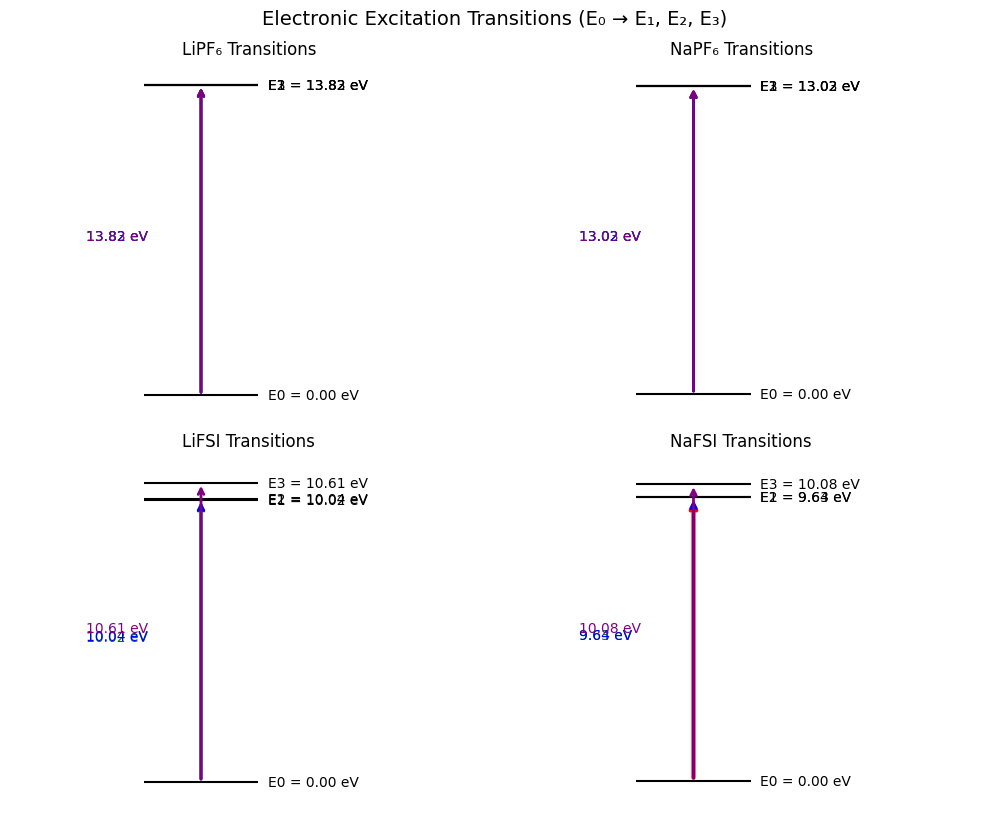

In [70]:
import matplotlib.pyplot as plt
import numpy as np

# Molecule excitation data: (Ground state energy in eV, Excited state energies in eV)
molecule_data = {
    "LiPF₆": {
        "E0": 0,
        "excited_states": [13.82, 13.82, 13.83]
    },
    "NaPF₆": {
        "E0": 0,
        "excited_states": [13.02, 13.02, 13.03]
    },
    "LiFSI": {
        "E0": 0,
        "excited_states": [10.02, 10.04, 10.61]
    },
    "NaFSI": {
        "E0": 0,
        "excited_states": [9.63, 9.64, 10.08]
    },
}

# Colors for transitions
colors = ['green', 'blue', 'purple']

# Find the most photo-sensitive transition (minimum E01)
min_energy = float('inf')
most_sensitive = None

for mol, data in molecule_data.items():
    e01 = data['excited_states'][0]
    if e01 < min_energy:
        min_energy = e01
        most_sensitive = mol

# Plot transitions per molecule
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, (mol, data) in enumerate(molecule_data.items()):
    ax = axes[i]
    E0 = data["E0"]
    excited = data["excited_states"]
    y_vals = [E0] + excited
    x = np.zeros(len(y_vals))

    # Plot energy levels
    for j, y in enumerate(y_vals):
        ax.hlines(y, xmin=-0.3, xmax=0.3, colors='black')
        ax.text(0.35, y, f"E{j} = {y:.2f} eV", va='center')

    # Plot transitions from E0 to E1-E3
    for j in range(1, 4):
        label = f"E₀{j}"
        arrowprops = dict(arrowstyle="->", lw=2, color=colors[j-1])
        if mol == most_sensitive and j == 1:
            arrowprops["lw"] = 3
            arrowprops["color"] = 'red'
            label += " (most photo-sensitive)"
        ax.annotate("", xy=(0, y_vals[j]), xytext=(0, E0), arrowprops=arrowprops)
        ax.text(-0.6, (E0 + y_vals[j]) / 2, f"{y_vals[j] - E0:.2f} eV", color=colors[j-1])

    ax.set_title(f"{mol} Transitions")
    ax.set_xlim(-1, 1.5)
    ax.set_ylim(-1, max(excited) + 1)
    ax.set_ylabel("Energy (eV)")
    ax.axis('off')

plt.tight_layout()
plt.suptitle("Electronic Excitation Transitions (E₀ → E₁, E₂, E₃)", y=1.02, fontsize=14)
plt.show()


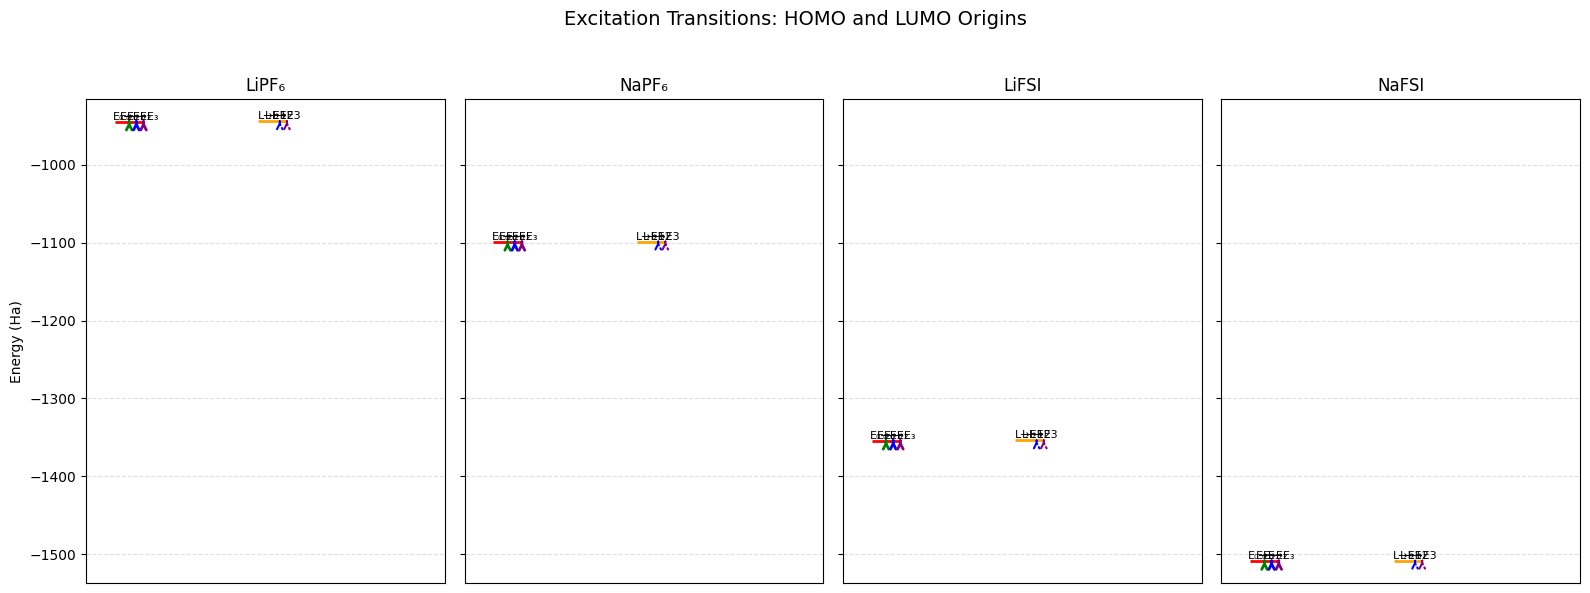

In [71]:
import matplotlib.pyplot as plt

# Sample excitation energies (in Hartree) for four molecules
# Format: (E_ground, E1, E2, E3)
excitation_data = {
    "LiPF₆": [-944.752162, -944.244458, -944.244278, -944.243853],
    "NaPF₆": [-1099.148004, -1098.669495, -1098.669386, -1098.669340],
    "LiFSI": [-1354.378187, -1354.010028, -1354.009274, -1353.988099],
    "NaFSI": [-1508.776842, -1508.422931, -1508.422424, -1508.406577],
}

# Plot settings
colors = ['green', 'blue', 'purple']
labels = ['E₀→E₁', 'E₀→E₂', 'E₀→E₃']
arrow_gap = 0.05  # spacing between arrows

fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=True)
for ax, (molecule, energies) in zip(axes, excitation_data.items()):
    E0, E1, E2, E3 = energies
    LUMO = E0 + (E1 - E0)  # hypothetical LUMO energy = HOMO + first transition energy

    # Plot E0 and LUMO
    ax.hlines(E0, 0.9, 1.1, color='red', linewidth=2, label="E₀ (HOMO)")
    ax.hlines(LUMO, 1.9, 2.1, color='orange', linewidth=2, label="LUMO (est.)")

    # Draw arrows from HOMO (E0)
    for i, Ei in enumerate([E1, E2, E3]):
        x = 1 + i * arrow_gap
        ax.annotate("", xy=(x, Ei), xytext=(x, E0),
                    arrowprops=dict(arrowstyle="->", color=colors[i], lw=2))
        ax.text(x, (E0 + Ei)/2, labels[i], fontsize=8, ha='center', va='bottom')

    # Draw arrows from LUMO
    for i, Ei in enumerate([E1, E2, E3]):
        x = 2 + i * arrow_gap
        ax.annotate("", xy=(x, Ei), xytext=(x, LUMO),
                    arrowprops=dict(arrowstyle="->", color=colors[i], lw=1.5, linestyle='dashed'))
        ax.text(x, (LUMO + Ei)/2, f"L→E{i+1}", fontsize=8, ha='center', va='bottom')

    ax.set_title(molecule)
    ax.set_xlim(0.7, 3.2)
    ax.set_xticks([])
    ax.grid(True, linestyle='--', alpha=0.4)

axes[0].set_ylabel("Energy (Ha)")
fig.suptitle("Excitation Transitions: HOMO and LUMO Origins", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("Excitation_Transitions_HOMO_LUMO.png", dpi=300)
plt.show()


In [1]:
from pyscf import gto, scf
import numpy as np

# ──────────────────────────────────────────────────────────────
# 1. Define the LiPF6 molecule (neutral Li+ · PF6– pair)
#    - P–F bond length ≈ 1.57 Å (ideal octahedron)
#    - Li+ placed 3 Å from P along +x for simplicity
# ──────────────────────────────────────────────────────────────
mol = gto.Mole()
mol.atom = '''
P        -0.000000        0.000000        0.207689
F         0.000000        1.159716       -1.114057
F        -0.000000       -1.187351        1.269191
F        -1.609678        0.000000        0.083000
F         1.609678       -0.000000        0.083000
F        -0.000000       -1.159716       -1.114057
F         0.000000        1.187351        1.269191
Li        0.000000        0.000000       -2.467253
'''
mol.basis  = 'cc-pVDZ' #'631g*'         # minimal basis for quick tests
mol.charge = 0                # Li+ + PF6– → neutral overall
mol.spin   = 0                # closed‑shell RHF
mol.build()

# ──────────────────────────────────────────────────────────────
# 2. Hartree–Fock calculation
# ──────────────────────────────────────────────────────────────
mf = scf.RHF(mol)
mf.kernel()

# ──────────────────────────────────────────────────────────────
# 3. Orbital energies and occupation analysis
# ──────────────────────────────────────────────────────────────
mo_energies  = mf.mo_energy
n_electrons  = mol.nelectron

print("\n📊  Orbital Energies (LiPF₆):")
for i, e in enumerate(mo_energies):
    occ = "occupied" if i < n_electrons // 2 else "virtual"
    print(f"  Orbital {i:2d} : {e: .6f} Ha   →  {occ}")

# ──────────────────────────────────────────────────────────────
# 4. Simple active‑space suggestions
#    • Freeze very low‑lying core orbitals (e < −0.8 Ha)
#    • Remove high virtuals            (e >  +0.5 Ha)
#    Adjust thresholds to taste!
# ──────────────────────────────────────────────────────────────
core_threshold    = -0.8
virtual_threshold =  0.5

frozen  = [i for i, e in enumerate(mo_energies) if e < core_threshold]
removed = [i for i, e in enumerate(mo_energies) if e > virtual_threshold]

print("\nSuggested core orbitals to freeze :", frozen)
print("Suggested high virtuals to remove :", removed)
print("Active orbitals (keep the rest!)")


converged SCF energy = -945.081392208818

📊  Orbital Energies (LiPF₆):
  Orbital  0 : -80.275622 Ha   →  occupied
  Orbital  1 : -26.321234 Ha   →  occupied
  Orbital  2 : -26.321222 Ha   →  occupied
  Orbital  3 : -26.305222 Ha   →  occupied
  Orbital  4 : -26.305221 Ha   →  occupied
  Orbital  5 : -26.304625 Ha   →  occupied
  Orbital  6 : -26.304614 Ha   →  occupied
  Orbital  7 : -7.766809 Ha   →  occupied
  Orbital  8 : -5.667646 Ha   →  occupied
  Orbital  9 : -5.667318 Ha   →  occupied
  Orbital 10 : -5.667068 Ha   →  occupied
  Orbital 11 : -2.519317 Ha   →  occupied
  Orbital 12 : -1.689192 Ha   →  occupied
  Orbital 13 : -1.615776 Ha   →  occupied
  Orbital 14 : -1.612101 Ha   →  occupied
  Orbital 15 : -1.611174 Ha   →  occupied
  Orbital 16 : -1.584062 Ha   →  occupied
  Orbital 17 : -1.577856 Ha   →  occupied
  Orbital 18 : -0.932687 Ha   →  occupied
  Orbital 19 : -0.803652 Ha   →  occupied
  Orbital 20 : -0.801482 Ha   →  occupied
  Orbital 21 : -0.794544 Ha   →  occupie

In [4]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_algorithms import VQE
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# ──────────────────────────────────────────────────────────────────────────────
# 1.  Geometry
# ──────────────────────────────────────────────────────────────────────────────
lipf6_geometry = (
    "P 0.0000 0.0000 0.2077; "
    "F 0.0000 1.1597 -1.1141; "
    "F 0.0000 -1.1874 1.2692; "
    "F -1.6097 0.0000 0.0830; "
    "F 1.6097 0.0000 0.0830; "
    "F 0.0000 -1.1597 -1.1141; "
    "F 0.0000 1.1874 1.2692; "
    "Li 0.0000 0.0000 -2.4673"
)

driver = PySCFDriver(atom=lipf6_geometry,
                     basis='cc-pVDZ', #"631g*",
                     charge=0,
                     spin=0,
                     unit=DistanceUnit.ANGSTROM)
problem = driver.run()

print("── Original HF problem ─────────────────────────")
print("Spatial orbitals :", problem.num_spatial_orbitals)
print("Spin  orbitals   :", problem.num_spin_orbitals)
na, nb = problem.num_particles
print(f"Electrons        : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 2.  Freeze‑core + trim high‑energy virtuals
# ──────────────────────────────────────────────────────────────────────────────
freeze_core     = list(range(0, 31))                            # lowest 22 MOs
remove_orbitals = list(range(40, problem.num_spatial_orbitals)) # 29 … 75

fc = FreezeCoreTransformer(freeze_core=False,
                           remove_orbitals=remove_orbitals+freeze_core)
problem_red = fc.transform(problem)

# Show what survived this step
all_orbs     = set(range(problem.num_spatial_orbitals))
frozen_orbs  = set(freeze_core)
removed_orbs = set(remove_orbitals)
kept_fc      = sorted(all_orbs - frozen_orbs - removed_orbs)

print("── After FreezeCoreTransformer ────────────────")
print("Frozen orbitals   :", sorted(freeze_core))
print("Removed virtuals  :", sorted(remove_orbitals))
print("Kept orbitals     :", kept_fc)
print("Spatial orbitals  :", problem_red.num_spatial_orbitals, "\n")
na, nb = problem_red.num_particles
print(f"Electrons        : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 3.  Active‑space reduction (6 e⁻ in 4 MOs)
# ──────────────────────────────────────────────────────────────────────────────
# Choose which of the kept orbitals will be active.
# Example below: take the first four kept orbitals (indices 0,1,2,3 in problem_red).
active_orbs_reduced = [2, 3, 4, 5, 6]          # change if you prefer a different window
ast = ActiveSpaceTransformer(
    num_electrons=6,
    num_spatial_orbitals=5,
    active_orbitals=active_orbs_reduced
)
problem_act = ast.transform(problem_red)

# Map those active indices back to original PySCF numbering
active_original = [kept_fc[i] for i in active_orbs_reduced]

print("── Active space ───────────────────────────────")
print("Active orbitals (re‑indexed) :", active_orbs_reduced)
print("Active orbitals (original HF):", active_original)
print("Spatial orbitals              :", problem_act.num_spatial_orbitals)
na, nb = problem_act.num_particles
print(f"Electrons                     : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 4.  Qubit mapping, ansatz, VQE
# ──────────────────────────────────────────────────────────────────────────────
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(problem_act.second_q_ops()[0])

init_state = HartreeFock(problem_act.num_spatial_orbitals,
                         problem_act.num_particles, mapper)
ansatz = UCCSD(problem_act.num_spatial_orbitals,
               problem_act.num_particles, mapper,
               initial_state=init_state)

vqe = VQE(estimator=Estimator(),
          ansatz=ansatz,
          optimizer=COBYLA(maxiter=10000))
vqe.initial_point = [0.0] * ansatz.num_parameters

gs_solver = GroundStateEigensolver(mapper, vqe)
result = gs_solver.solve(problem_act)

print("── VQE result ────────────────────────────────")
print("Qubits used          :", qubit_hamiltonian.num_qubits)
print("Ground‑state energy  :", result.total_energies[0].real, "Ha")
print("Optimal parameters   :", result.raw_result.optimal_point)

── Original HF problem ─────────────────────────
Spatial orbitals : 116
Spin  orbitals   : 232
Electrons        : 72 (36 α, 36 β)

── After FreezeCoreTransformer ────────────────
Frozen orbitals   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Removed virtuals  : [40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115]
Kept orbitals     : [31, 32, 33, 34, 35, 36, 37, 38, 39]
Spatial orbitals  : 9 

Electrons        : 10 (5 α, 5 β)

── Active space ───────────────────────────────
Active orbitals (re‑indexed) : [2, 3, 4, 5, 6]
Active orbitals (original HF): [33, 34, 35, 36, 37]
Spatial orbitals              : 5
Electrons                     : 6 (3 α, 3 β)

── 

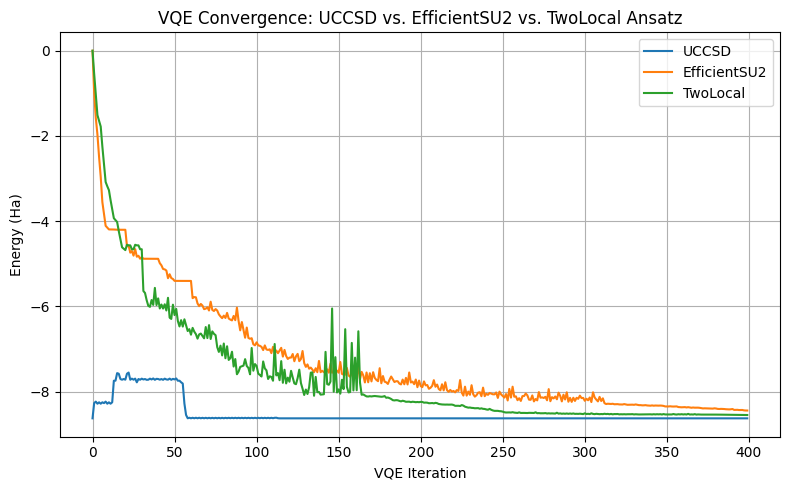

UCCSD:
  Energy: -945.0813874589475
  Iterations: 400
  Parameters: 54
  Depth: 55
  Time (s): 576.6
----------------------------------------
EfficientSU2:
  Energy: -944.8981691388652
  Iterations: 400
  Parameters: 60
  Depth: 17
  Time (s): 20.95
----------------------------------------
TwoLocal:
  Energy: -945.0033930585149
  Iterations: 400
  Parameters: 30
  Depth: 30
  Time (s): 20.97
----------------------------------------


In [5]:
import matplotlib.pyplot as plt
import time
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2, TwoLocal
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# Assume 'problem_act' is your active-space reduced problem from earlier
mapper = JordanWignerMapper()
init_state = HartreeFock(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper)

# Storage for reporting
summary = {}

### ---------- UCCSD ----------
energy_history_uccsd = []
def callback_uccsd(eval_count, params, energy, stddev):
    energy_history_uccsd.append(energy)

ansatz_uccsd = UCCSD(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper, initial_state=init_state)
optimizer_uccsd = COBYLA(maxiter=400)

start = time.time()
vqe_uccsd = VQE(Estimator(), ansatz=ansatz_uccsd, optimizer=optimizer_uccsd, callback=callback_uccsd, initial_point=[0.0]*ansatz_uccsd.num_parameters)
solver_uccsd = GroundStateEigensolver(mapper, vqe_uccsd)
result_uccsd = solver_uccsd.solve(problem_act)
end = time.time()

summary['UCCSD'] = {
    'Energy': result_uccsd.total_energies[0].real,
    'Iterations': len(energy_history_uccsd),
    'Parameters': ansatz_uccsd.num_parameters,
    'Depth': ansatz_uccsd.decompose().depth(),
    'Time (s)': round(end - start, 2)
}

### ---------- EfficientSU2 ----------
energy_history_he = []
def callback_he(eval_count, params, energy, stddev):
    energy_history_he.append(energy)

ansatz_he = EfficientSU2(problem_act.num_spatial_orbitals*2, reps=2)
optimizer_he = COBYLA(maxiter=400)

start = time.time()
vqe_he = VQE(Estimator(), ansatz=ansatz_he, optimizer=optimizer_he, callback=callback_he, initial_point=[0.0]*ansatz_he.num_parameters)
solver_he = GroundStateEigensolver(mapper, vqe_he)
result_he = solver_he.solve(problem_act)
end = time.time()

summary['EfficientSU2'] = {
    'Energy': result_he.total_energies[0].real,
    'Iterations': len(energy_history_he),
    'Parameters': ansatz_he.num_parameters,
    'Depth': ansatz_he.decompose().depth(),
    'Time (s)': round(end - start, 2)
}

### ---------- TwoLocal ----------
energy_history_tl = []
def callback_tl(eval_count, params, energy, stddev):
    energy_history_tl.append(energy)

ansatz_tl = TwoLocal(num_qubits=problem_act.num_spatial_orbitals*2, rotation_blocks='ry', entanglement_blocks='cz', reps=2, entanglement='full')
optimizer_tl = COBYLA(maxiter=400)

start = time.time()
vqe_tl = VQE(Estimator(), ansatz=ansatz_tl, optimizer=optimizer_tl, callback=callback_tl, initial_point=[0.0]*ansatz_tl.num_parameters)
solver_tl = GroundStateEigensolver(mapper, vqe_tl)
result_tl = solver_tl.solve(problem_act)
end = time.time()

summary['TwoLocal'] = {
    'Energy': result_tl.total_energies[0].real,
    'Iterations': len(energy_history_tl),
    'Parameters': ansatz_tl.num_parameters,
    'Depth': ansatz_tl.decompose().depth(),
    'Time (s)': round(end - start, 2)
}

### ---------- Plot ----------
plt.figure(figsize=(8, 5))
plt.plot(energy_history_uccsd, label='UCCSD')
plt.plot(energy_history_he, label='EfficientSU2')
plt.plot(energy_history_tl, label='TwoLocal')
plt.xlabel('VQE Iteration')
plt.ylabel('Energy (Ha)')
plt.title('VQE Convergence: UCCSD vs. EfficientSU2 vs. TwoLocal Ansatz')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### ---------- Print Summary ----------
for method, stats in summary.items():
    print(f"{method}:")
    for key, value in stats.items():
        print(f"  {key}: {value}")
    print("-" * 40)


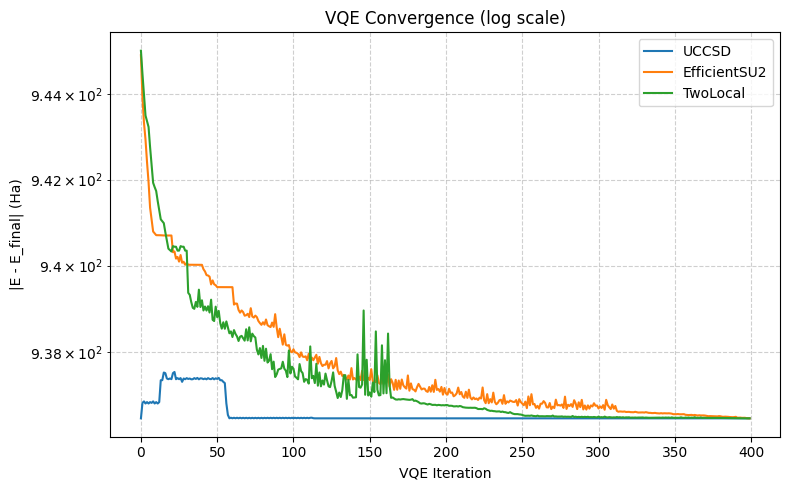

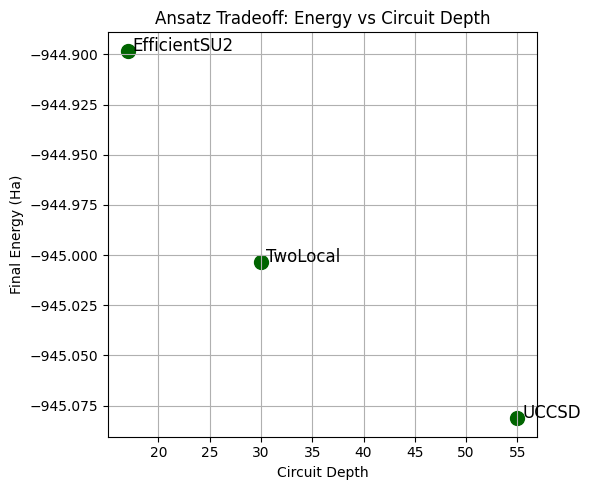


📋 VQE Ansatz Summary:
Hartree–Fock Energy = -945.081387 Ha

UCCSD:
  Energy         : -945.0813874589475
  Correlation (%): 0.0
  Iterations     : 400
  Time (s)       : 556.99
  Time/Iter (s)  : 1.392
  Parameters     : 54
  Depth          : 55
----------------------------------------
EfficientSU2:
  Energy         : -944.8981691388652
  Correlation (%): -0.02
  Iterations     : 400
  Time (s)       : 21.09
  Time/Iter (s)  : 0.053
  Parameters     : 60
  Depth          : 17
----------------------------------------
TwoLocal:
  Energy         : -945.0033930585149
  Correlation (%): -0.01
  Iterations     : 400
  Time (s)       : 21.27
  Time/Iter (s)  : 0.053
  Parameters     : 30
  Depth          : 30
----------------------------------------


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import time
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2, TwoLocal
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# --- Assume problem_act already defined from your active space setup ---
mapper = JordanWignerMapper()
init_state = HartreeFock(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper)
hf_energy = problem_act.reference_energy

summary = {}
convergence_logs = {}

# --- Benchmarking function ---
def run_vqe(ansatz, name, maxiter=400):
    energy_history = []

    def callback(eval_count, params, energy, stddev):
        energy_history.append(energy)

    optimizer = COBYLA(maxiter=maxiter)
    vqe = VQE(Estimator(), ansatz=ansatz, optimizer=optimizer,
              callback=callback, initial_point=[0.0] * ansatz.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)

    start = time.time()
    result = solver.solve(problem_act)
    end = time.time()

    final_energy = result.total_energies[0].real
    iterations = len(energy_history)
    duration = round(end - start, 2)
    time_per_iter = round(duration / iterations, 3) if iterations > 0 else 0.0
    depth = ansatz.decompose().depth()

    summary[name] = {
        'Energy': final_energy,
        'Correlation (%)': round(100 * (hf_energy - final_energy) / abs(hf_energy), 2),
        'Iterations': iterations,
        'Time (s)': duration,
        'Time/Iter (s)': time_per_iter,
        'Parameters': ansatz.num_parameters,
        'Depth': depth,
    }
    convergence_logs[name] = energy_history


# --- Run UCCSD ---
uccsd = UCCSD(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper, initial_state=init_state)
run_vqe(uccsd, "UCCSD", maxiter=400)

# --- Run EfficientSU2 ---
he = EfficientSU2(problem_act.num_spatial_orbitals * 2, reps=2)
run_vqe(he, "EfficientSU2")

# --- Run TwoLocal ---
tl = TwoLocal(num_qubits=problem_act.num_spatial_orbitals * 2,
              rotation_blocks='ry', entanglement_blocks='cz', reps=2, entanglement='full')
run_vqe(tl, "TwoLocal")

# === 📉 Plot: Convergence as Energy Error ===
plt.figure(figsize=(8, 5))
for name, energies in convergence_logs.items():
    final_energy = summary[name]['Energy']
    energy_errors = np.abs(np.array(energies) - final_energy)
    plt.semilogy(energy_errors, label=name)

plt.xlabel('VQE Iteration')
plt.ylabel('|E - E_final| (Ha)')
plt.title('VQE Convergence (log scale)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("vqe_convergence_log_error.png", dpi=600)
plt.show()

# === ⚙️ Plot: Energy vs Depth Tradeoff ===
methods = list(summary.keys())
energies = [summary[m]['Energy'] for m in methods]
depths = [summary[m]['Depth'] for m in methods]

plt.figure(figsize=(6, 5))
plt.scatter(depths, energies, s=100, color='darkgreen')
for i, method in enumerate(methods):
    plt.text(depths[i] + 0.5, energies[i], method, fontsize=12)
plt.xlabel('Circuit Depth')
plt.ylabel('Final Energy (Ha)')
plt.title('Ansatz Tradeoff: Energy vs Circuit Depth')
plt.grid(True)
plt.tight_layout()
plt.savefig("vqe_energy_vs_depth.png", dpi=600)
plt.show()

# === 📊 Print Summary Table ===
print("\n📋 VQE Ansatz Summary:")
print(f"Hartree–Fock Energy = {hf_energy:.6f} Ha\n")
for method, stats in summary.items():
    print(f"{method}:")
    for key, value in stats.items():
        print(f"  {key:15s}: {value}")
    print("-" * 40)

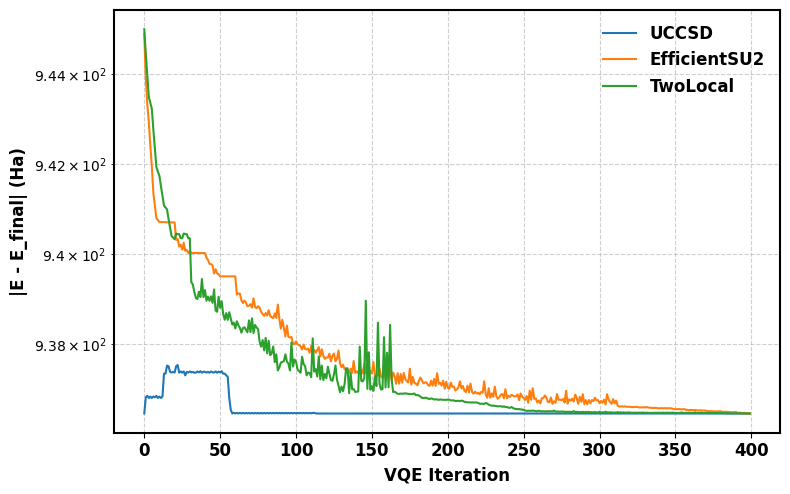

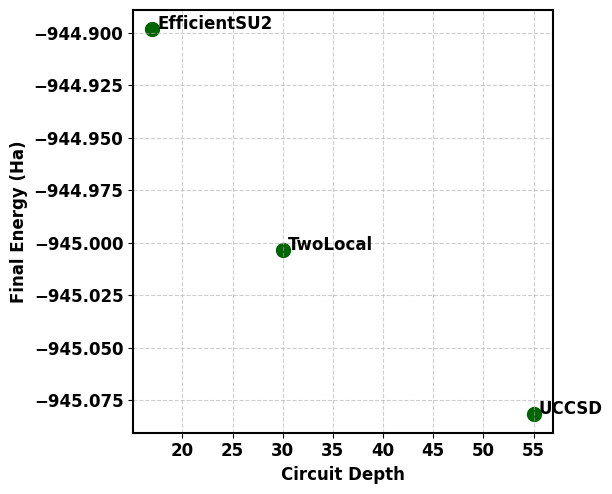

In [7]:
# === 📉 Plot: Convergence as Energy Error ===
from matplotlib.font_manager import FontProperties
plt.figure(figsize=(8, 5))
for name, energies in convergence_logs.items():
    final_energy = summary[name]['Energy']
    energy_errors = np.abs(np.array(energies) - final_energy)
    plt.semilogy(energy_errors, label=name)

plt.xlabel('VQE Iteration', fontsize=12, fontweight='bold')
plt.ylabel('|E - E_final| (Ha)', fontsize=12, fontweight='bold')
#plt.title('VQE Convergence (log scale)')
plt.legend(prop=FontProperties(weight='bold', size=12), frameon=False)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

plt.savefig("vqe_convergence_log_error.jpg", dpi=600, bbox_inches='tight')
plt.show()

# === ⚙️ Plot: Energy vs Depth Tradeoff ===
methods = list(summary.keys())
energies = [summary[m]['Energy'] for m in methods]
depths = [summary[m]['Depth'] for m in methods]

plt.figure(figsize=(6, 5))
plt.scatter(depths, energies, s=100, color='darkgreen')
for i, method in enumerate(methods):
    plt.text(depths[i] + 0.5, energies[i], method, fontsize=12, fontweight='bold')
plt.xlabel('Circuit Depth', fontsize=12, fontweight='bold')
plt.ylabel('Final Energy (Ha)', fontsize=12, fontweight='bold')
#plt.title('Ansatz Tradeoff: Energy vs Circuit Depth')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

plt.savefig("vqe_energy_vs_depth.jpg", dpi=600, bbox_inches='tight')
plt.show()

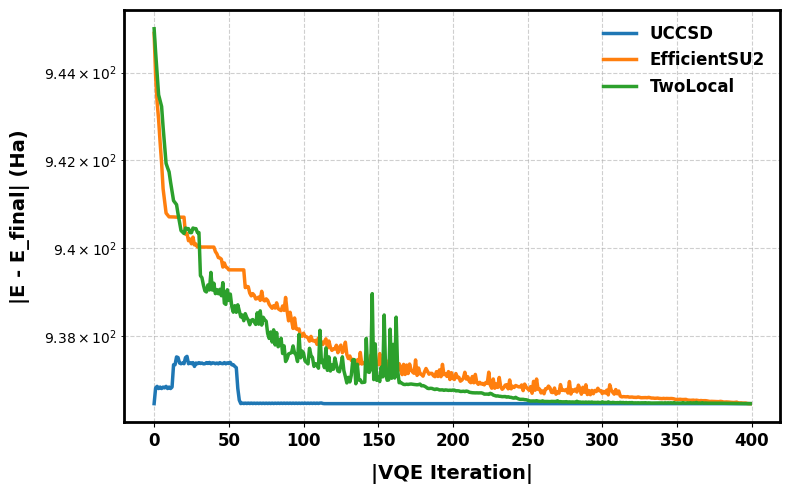

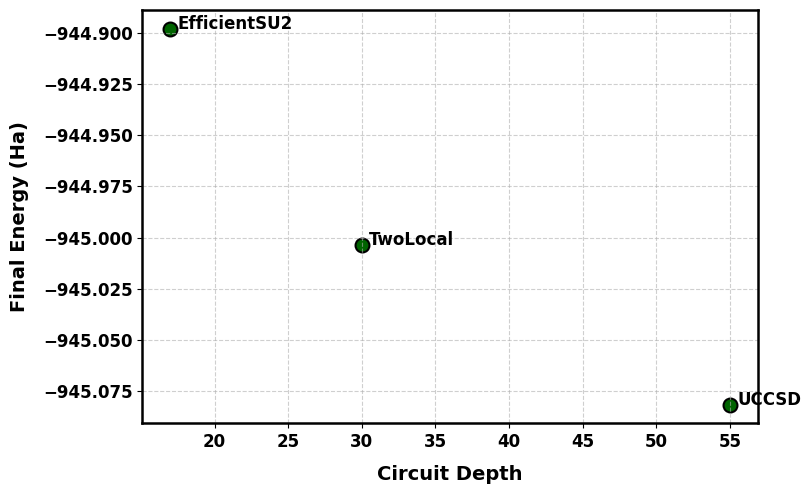

In [12]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import numpy as np

# === 📉 Plot: Convergence as Energy Error ===
plt.figure(figsize=(8, 5))
for name, energies in convergence_logs.items():
    final_energy = summary[name]['Energy']
    energy_errors = np.abs(np.array(energies) - final_energy)
    plt.semilogy(energy_errors, label=name, linewidth=2.5)  # Increased line thickness

plt.xlabel('|VQE Iteration|', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('|E - E_final| (Ha)', fontsize=14, fontweight='bold', labelpad=10)
plt.legend(prop=FontProperties(weight='bold', size=12), frameon=False)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()

# === Axis Border Thickness ===
ax = plt.gca()
for side in ['top', 'right', 'left', 'bottom']:
    ax.spines[side].set_linewidth(2)
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

plt.savefig("vqe_convergence_log_error.jpg", dpi=600, bbox_inches='tight')
plt.show()

# === ⚙️ Plot: Energy vs Depth Tradeoff ===
methods = list(summary.keys())
energies = [summary[m]['Energy'] for m in methods]
depths = [summary[m]['Depth'] for m in methods]

plt.figure(figsize=(8, 5))
plt.scatter(depths, energies, s=100, color='darkgreen', linewidth=1.5, edgecolor='black')  # Thicker edge for points
for i, method in enumerate(methods):
    plt.text(depths[i] + 0.5, energies[i], method, fontsize=12, fontweight='bold')

plt.xlabel('Circuit Depth', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Final Energy (Ha)', fontsize=14, fontweight='bold', labelpad=10)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()

# === Axis Border Thickness ===
ax = plt.gca()
for side in ['top', 'right', 'left', 'bottom']:
    ax.spines[side].set_linewidth(1.8)
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

plt.savefig("vqe_energy_vs_depth.jpg", dpi=600, bbox_inches='tight')
plt.show()



🧪 FCI Energy (exact): -945.093125 Ha


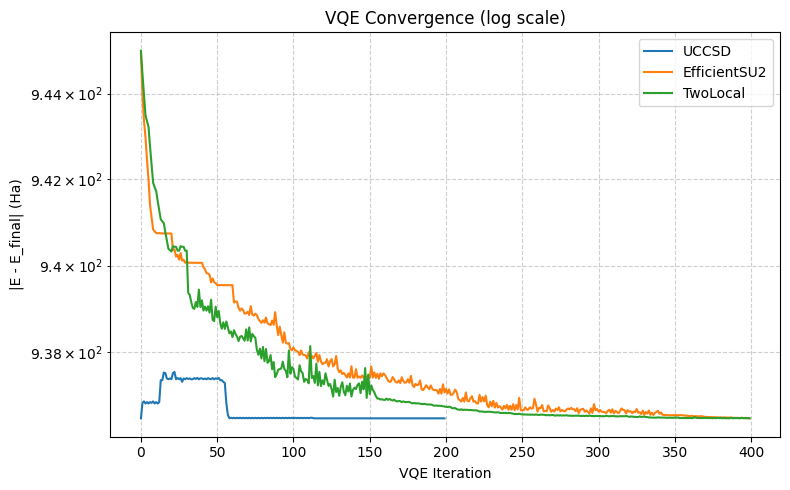

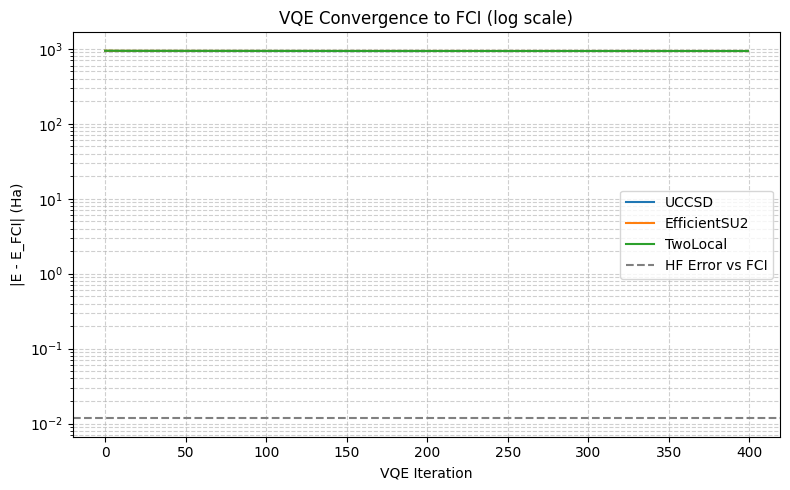

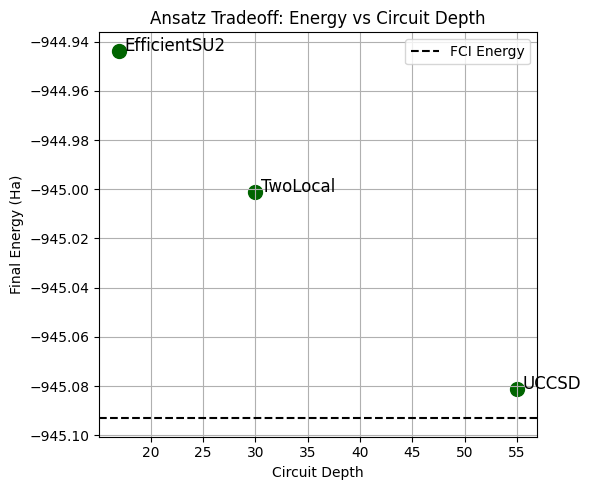


📋 VQE Ansatz Summary:
Hartree–Fock Energy = -945.081387 Ha
Exact FCI Energy    = -945.093125 Ha

UCCSD:
  Energy              : -945.0813870560454
  Recovered Corr. (%) : 0.0
  Iterations          : 200
  Time (s)            : 259.36
  Time/Iter (s)       : 1.297
  Parameters          : 54
  Depth               : 55
----------------------------------------
EfficientSU2:
  Energy              : -944.9436886537598
  Recovered Corr. (%) : -1173.12
  Iterations          : 400
  Time (s)            : 21.06
  Time/Iter (s)       : 0.053
  Parameters          : 60
  Depth               : 17
----------------------------------------
TwoLocal:
  Energy              : -945.0010767059288
  Recovered Corr. (%) : -684.2
  Iterations          : 400
  Time (s)            : 20.9
  Time/Iter (s)       : 0.052
  Parameters          : 30
  Depth               : 30
----------------------------------------


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import time
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2, TwoLocal
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# === Assumes problem_act is already defined (active space Hamiltonian) ===
mapper = JordanWignerMapper()
init_state = HartreeFock(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper)
hf_energy = problem_act.reference_energy

# === 🔬 Compute FCI energy ===
numpy_solver = NumPyMinimumEigensolver()
fci_solver = GroundStateEigensolver(mapper, numpy_solver)
fci_result = fci_solver.solve(problem_act)
fci_energy = fci_result.total_energies[0].real
print(f"\n🧪 FCI Energy (exact): {fci_energy:.6f} Ha")

summary = {}
convergence_logs = {}

# === Benchmarking Function ===
def run_vqe(ansatz, name, maxiter=400):
    energy_history = []

    def callback(eval_count, params, energy, stddev):
        energy_history.append(energy)

    optimizer = COBYLA(maxiter=maxiter)
    vqe = VQE(Estimator(), ansatz=ansatz, optimizer=optimizer,
              callback=callback, initial_point=[0.0] * ansatz.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)

    start = time.time()
    result = solver.solve(problem_act)
    end = time.time()

    final_energy = result.total_energies[0].real
    iterations = len(energy_history)
    duration = round(end - start, 2)
    time_per_iter = round(duration / iterations, 3) if iterations > 0 else 0.0
    depth = ansatz.decompose().depth()

    correlation_recovered = 100 * (hf_energy - final_energy) / (hf_energy - fci_energy) if hf_energy > fci_energy else 0.0

    summary[name] = {
        'Energy': final_energy,
        'Recovered Corr. (%)': round(correlation_recovered, 2),
        'Iterations': iterations,
        'Time (s)': duration,
        'Time/Iter (s)': time_per_iter,
        'Parameters': ansatz.num_parameters,
        'Depth': depth,
    }
    convergence_logs[name] = energy_history


# === Run VQE with UCCSD ===
uccsd = UCCSD(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper, initial_state=init_state)
run_vqe(uccsd, "UCCSD", maxiter=200)

# === Run VQE with EfficientSU2 ===
he = EfficientSU2(problem_act.num_spatial_orbitals * 2, reps=2)
run_vqe(he, "EfficientSU2")

# === Run VQE with TwoLocal ===
tl = TwoLocal(num_qubits=problem_act.num_spatial_orbitals * 2,
              rotation_blocks='ry', entanglement_blocks='cz', reps=2, entanglement='full')
run_vqe(tl, "TwoLocal")


# === 📉 Plot: Convergence as Energy Error ===
plt.figure(figsize=(8, 5))
for name, energies in convergence_logs.items():
    final_energy = summary[name]['Energy']
    energy_errors = np.abs(np.array(energies) - final_energy)
    plt.semilogy(energy_errors, label=name)

plt.xlabel('VQE Iteration')
plt.ylabel('|E - E_final| (Ha)')
plt.title('VQE Convergence (log scale)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("vqe_convergence_log_error.png", dpi=600)
plt.show()

# === 📉 Plot: Convergence to FCI ===
plt.figure(figsize=(8, 5))
for name, energies in convergence_logs.items():
    energy_errors = np.abs(np.array(energies) - fci_energy)
    plt.semilogy(energy_errors, label=name)

plt.axhline(np.abs(hf_energy - fci_energy), color='gray', linestyle='--', label='HF Error vs FCI')
plt.xlabel('VQE Iteration')
plt.ylabel('|E - E_FCI| (Ha)')
plt.title('VQE Convergence to FCI (log scale)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("vqe_convergence_vs_fci_log.png", dpi=600)
plt.show()

# === ⚙️ Plot: Energy vs Depth ===
methods = list(summary.keys())
energies = [summary[m]['Energy'] for m in methods]
depths = [summary[m]['Depth'] for m in methods]

plt.figure(figsize=(6, 5))
plt.scatter(depths, energies, s=100, color='darkgreen')
for i, method in enumerate(methods):
    plt.text(depths[i] + 0.5, energies[i], method, fontsize=12)
plt.axhline(y=fci_energy, linestyle='--', color='black', label='FCI Energy')
plt.xlabel('Circuit Depth')
plt.ylabel('Final Energy (Ha)')
plt.title('Ansatz Tradeoff: Energy vs Circuit Depth')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("vqe_energy_vs_depth.png", dpi=600)
plt.show()

# === 📊 Print Summary Table ===
print("\n📋 VQE Ansatz Summary:")
print(f"Hartree–Fock Energy = {hf_energy:.6f} Ha")
print(f"Exact FCI Energy    = {fci_energy:.6f} Ha\n")
for method, stats in summary.items():
    print(f"{method}:")
    for key, value in stats.items():
        print(f"  {key:20s}: {value}")
    print("-" * 40)

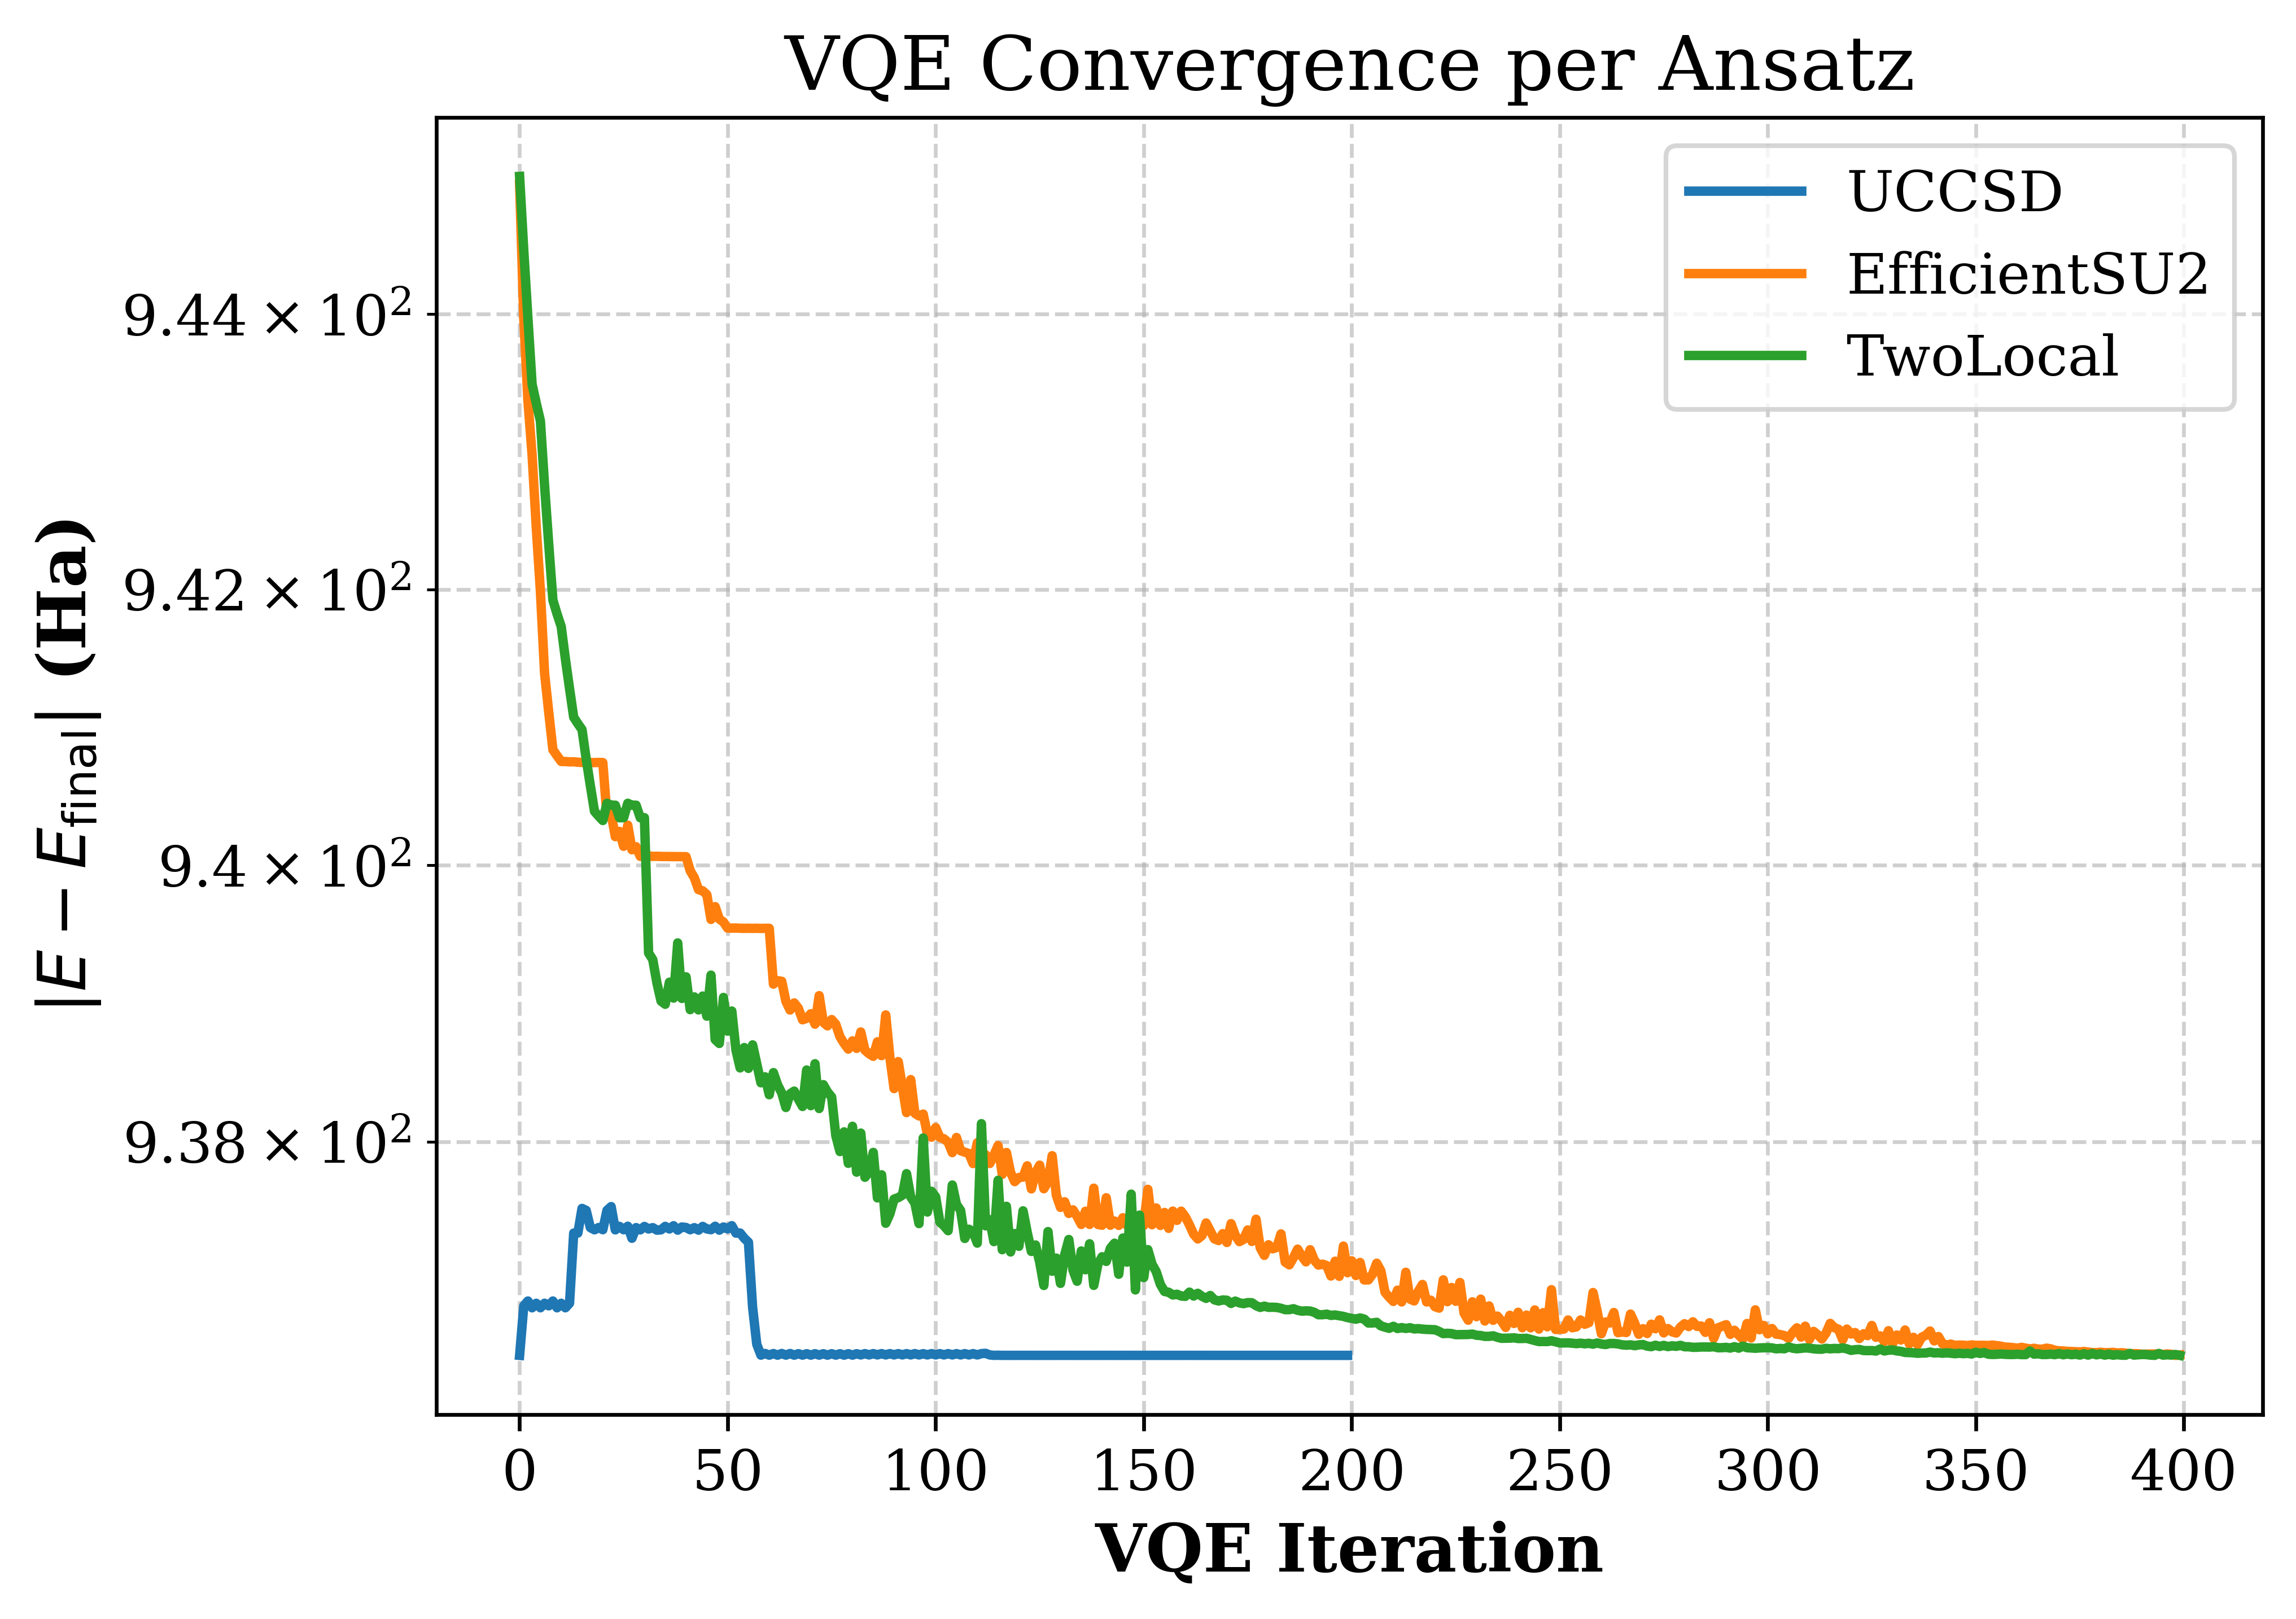

In [23]:
import matplotlib as mpl

# --- Apply publication-style formatting ---
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 15,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "figure.dpi": 600
})

# === 📉 VQE Convergence to Final Ansatz Energy ===
plt.figure(figsize=(7, 5))

for name, energies in convergence_logs.items():
    final_energy = summary[name]['Energy']
    energy_errors = np.abs(np.array(energies) - final_energy)
    plt.semilogy(energy_errors, label=name)

plt.xlabel('VQE Iteration', fontsize=14, fontweight='bold')
plt.ylabel(r'$|E - E_{\mathrm{final}}|$ (Ha)', fontsize=14, fontweight='bold')
plt.title('VQE Convergence per Ansatz')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("vqe_convergence_per_ansatz.jpg", dpi=600)
plt.show()

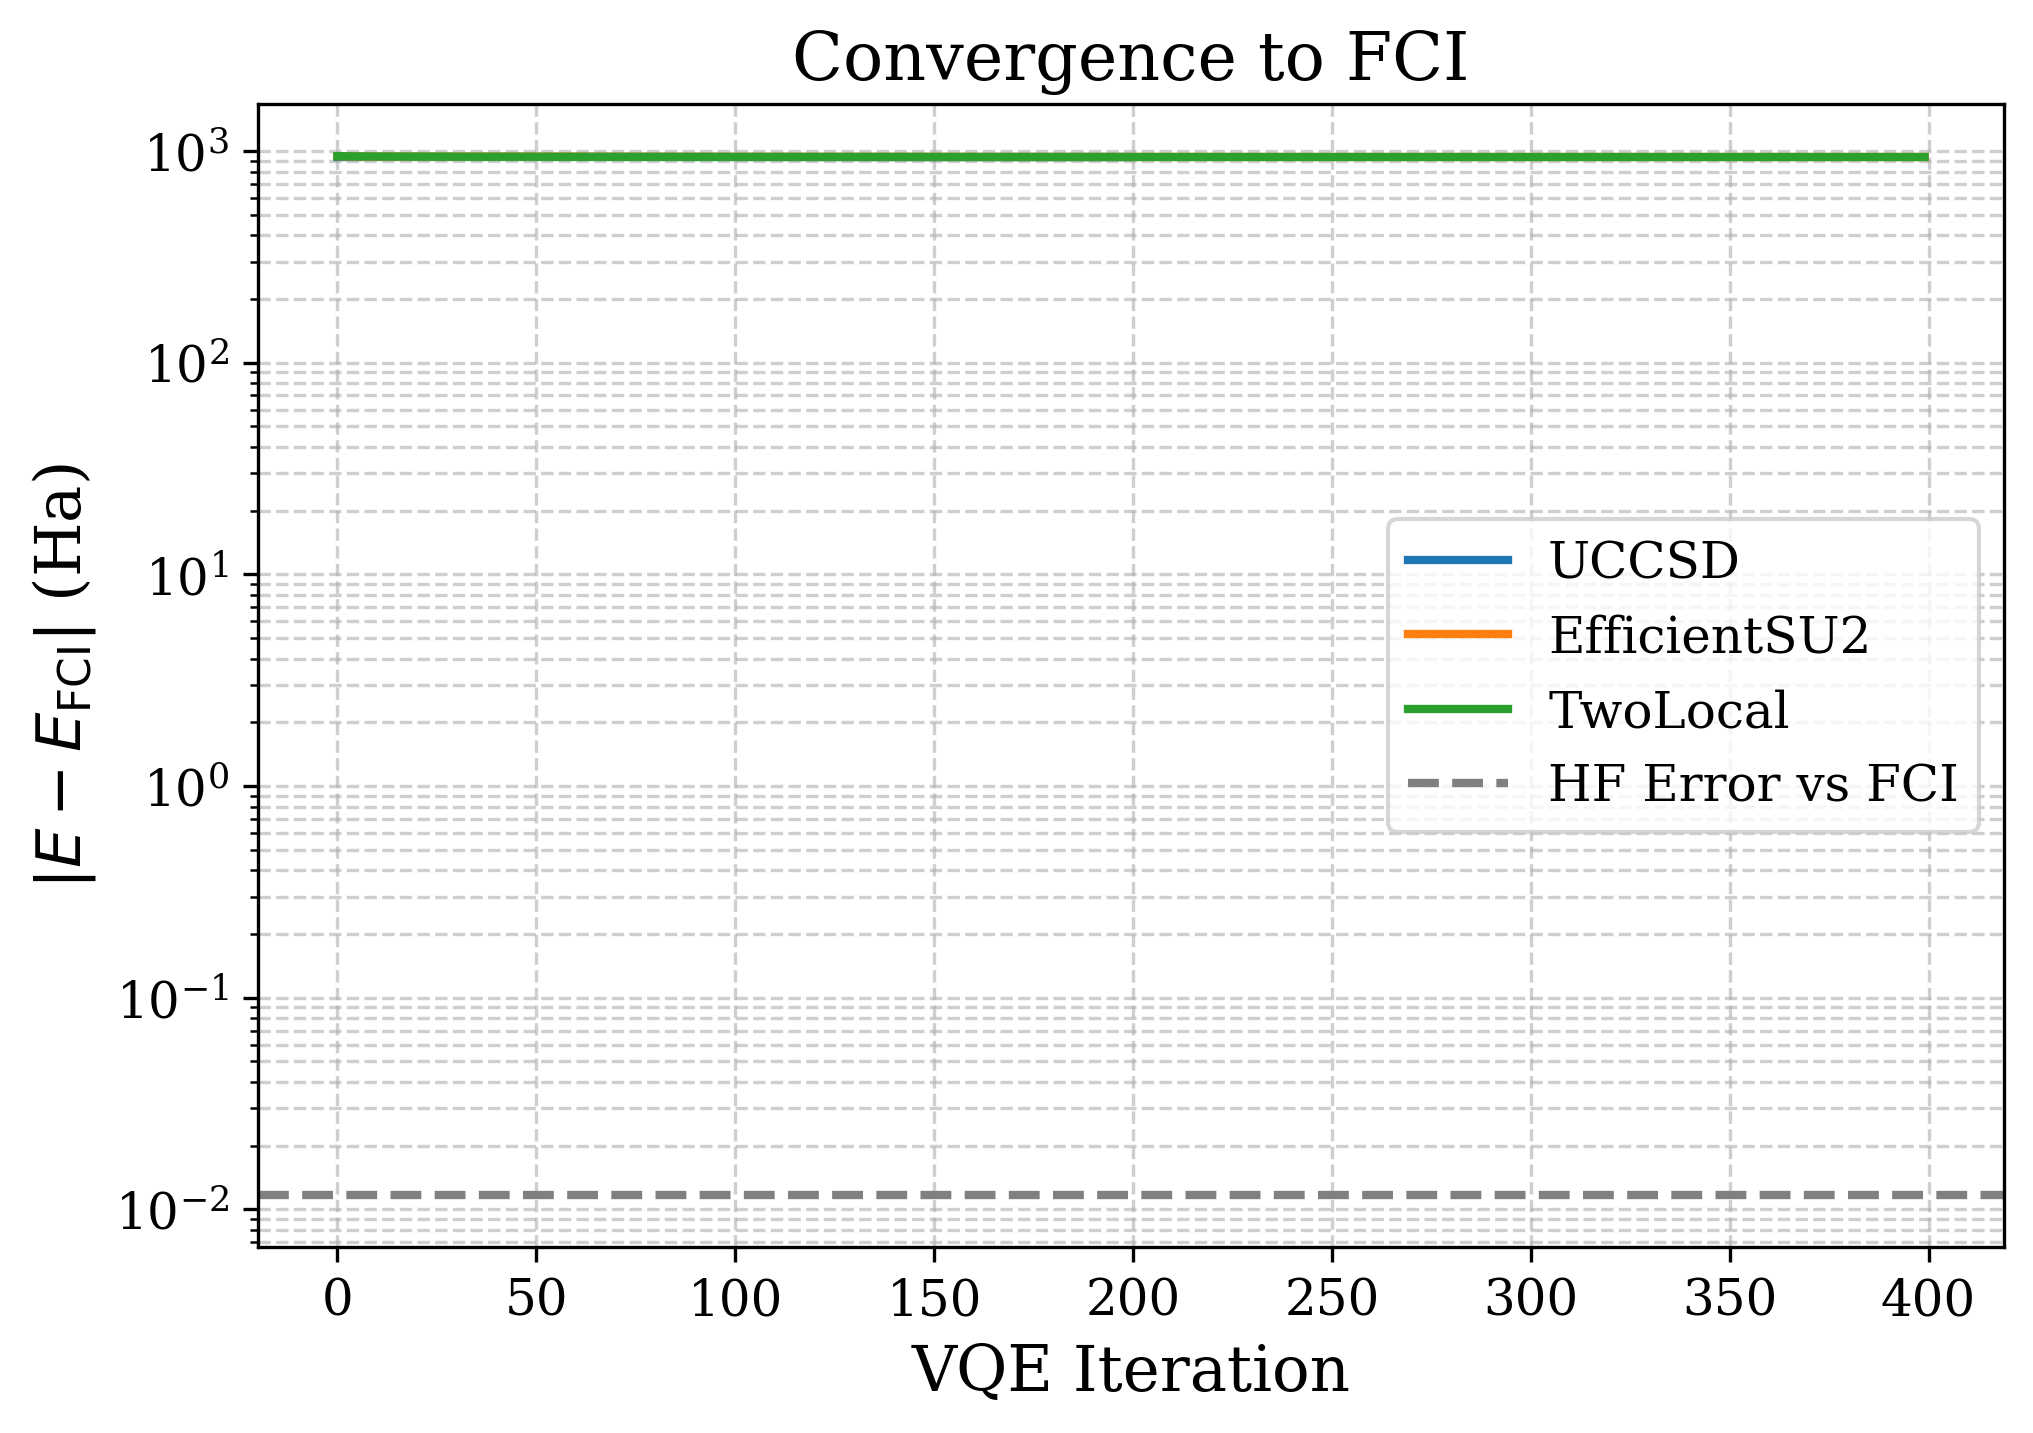

In [7]:
import matplotlib as mpl

# --- Apply publication-style formatting ---
mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 15,
    "axes.titlesize": 16,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "figure.dpi": 300
})

# === (a) Plot: Convergence to FCI ===
plt.figure(figsize=(7, 5))
for name, energies in convergence_logs.items():
    energy_errors = np.abs(np.array(energies) - fci_energy)
    plt.semilogy(energy_errors, label=name)

plt.axhline(np.abs(hf_energy - fci_energy), color='gray', linestyle='--', label='HF Error vs FCI')

plt.xlabel('VQE Iteration')
plt.ylabel(r'$|E - E_{\mathrm{FCI}}|$ (Ha)')
plt.title('Convergence to FCI')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("vqe_convergence_vs_fci_publication.png", dpi=600)
plt.show()


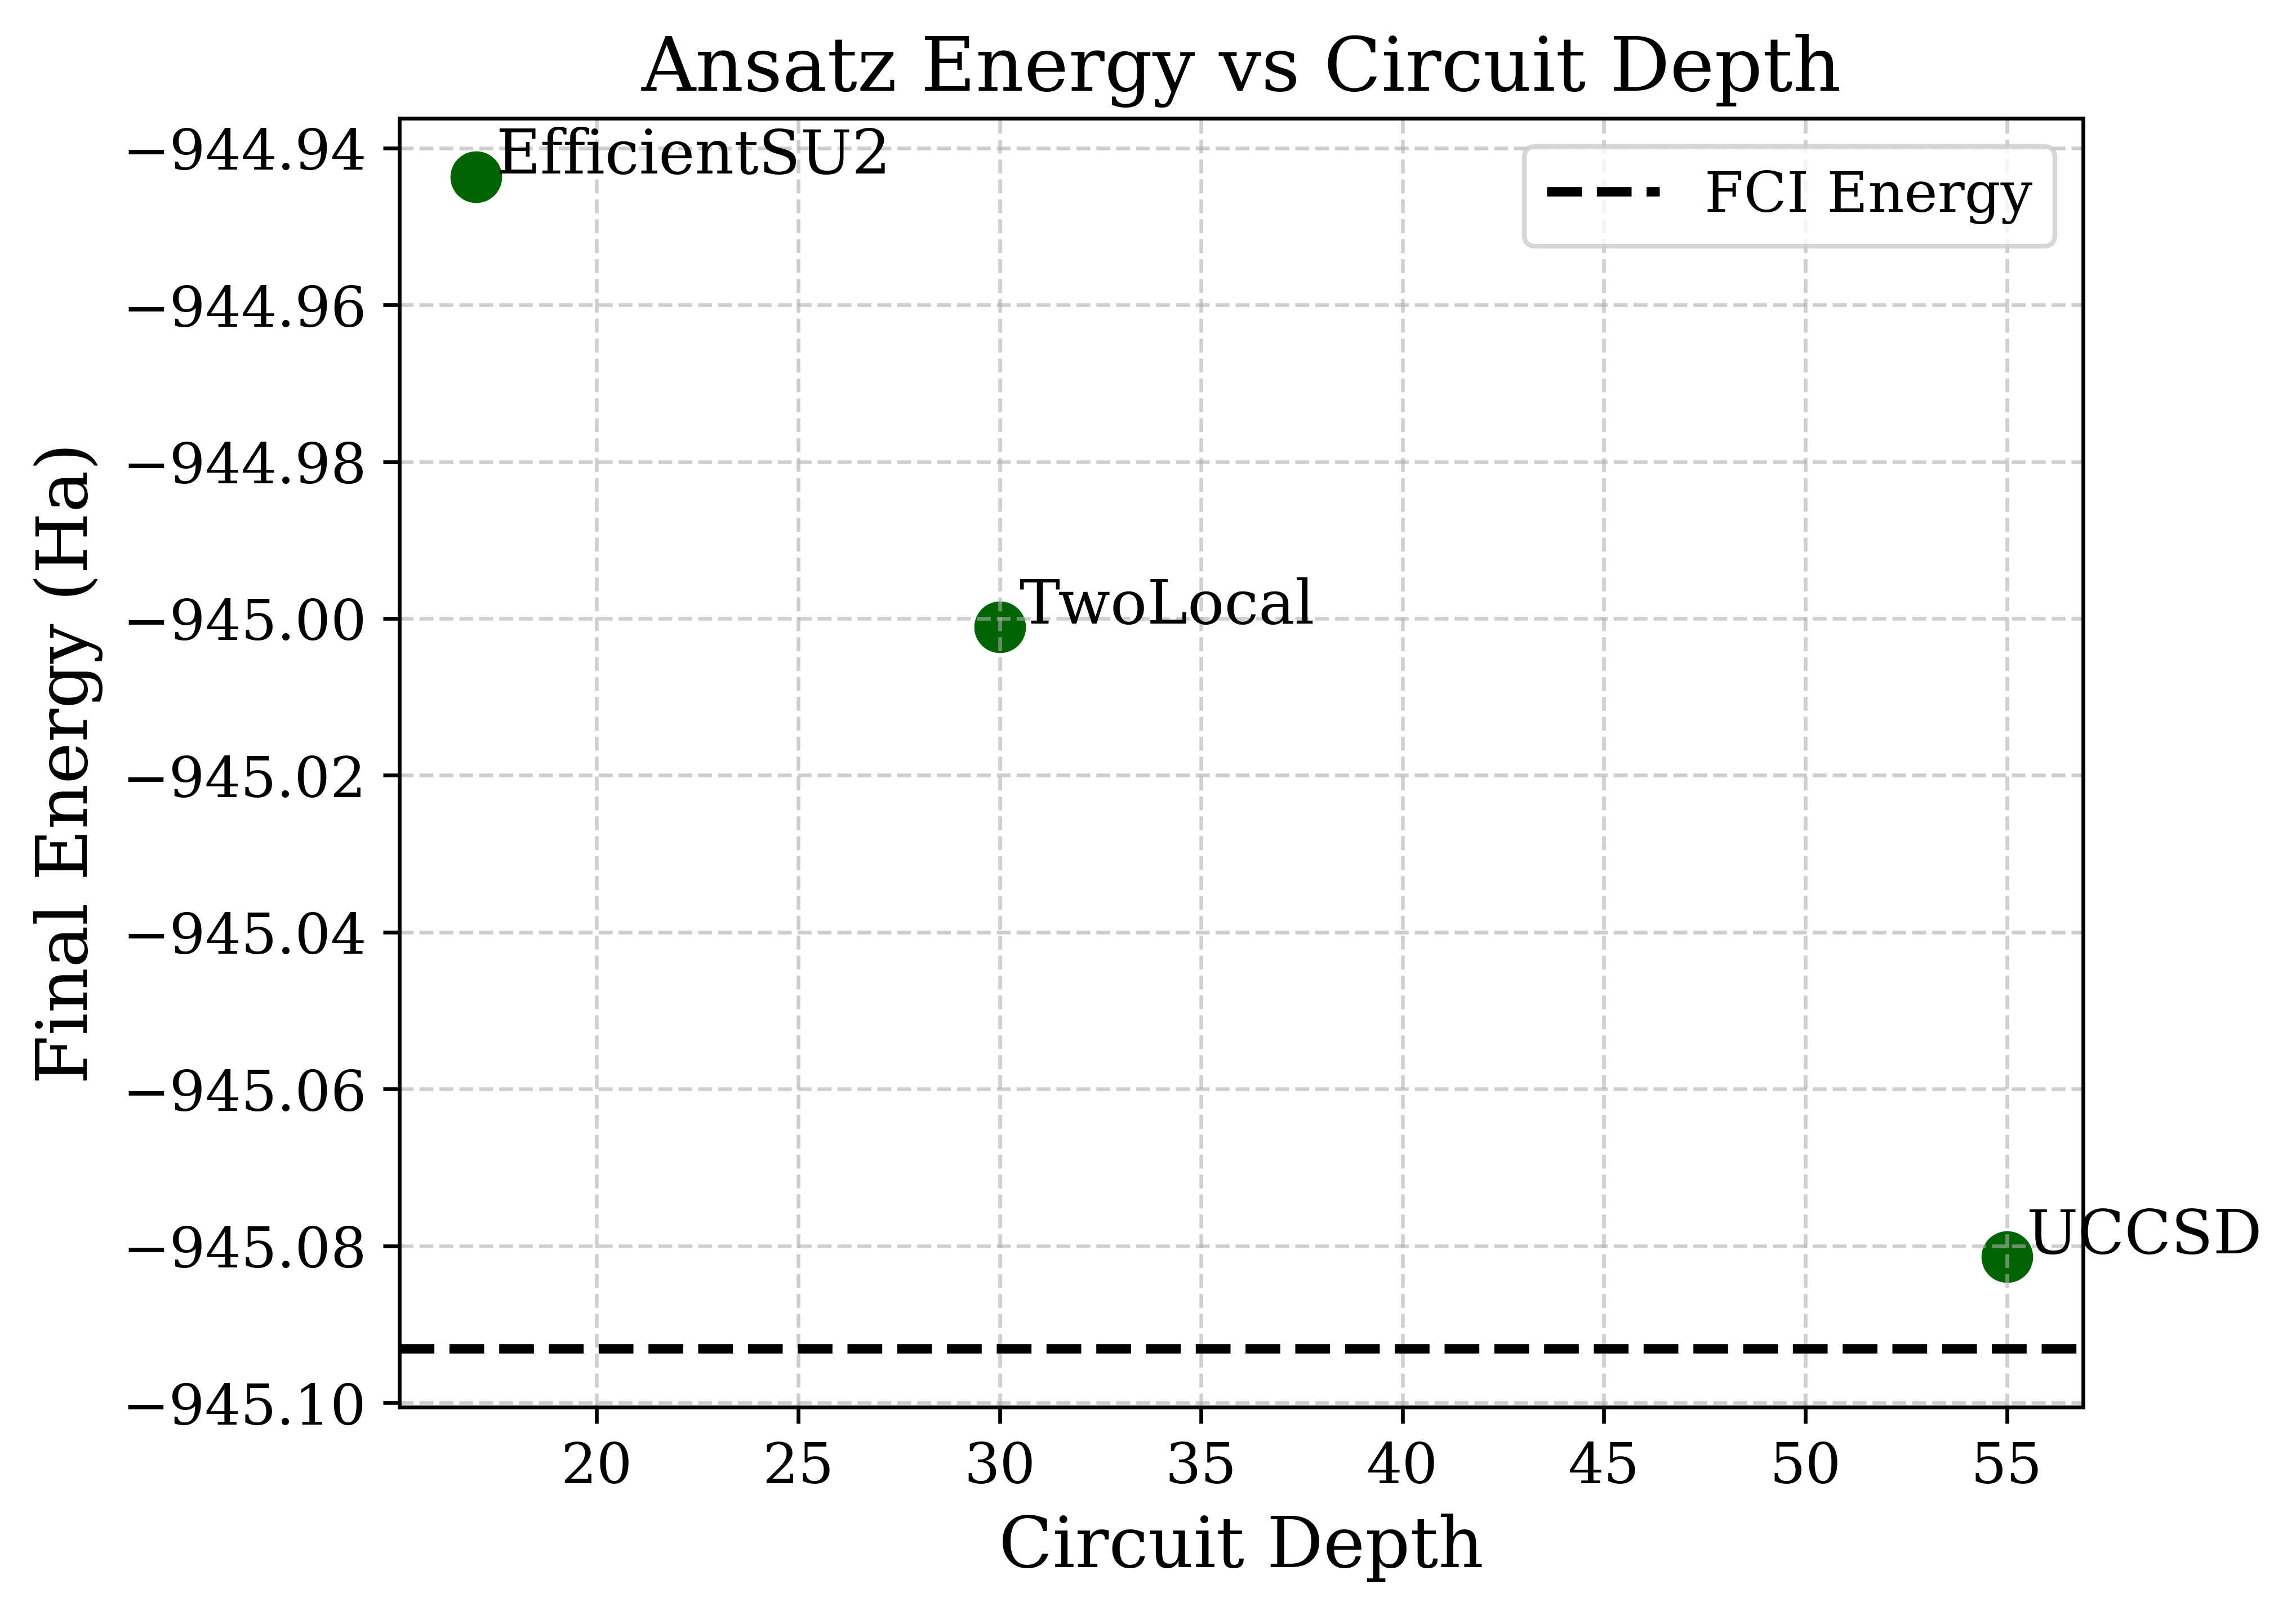

In [17]:
# === (b) Plot: Energy vs Depth ===
methods = list(summary.keys())
energies = [summary[m]['Energy'] for m in methods]
depths = [summary[m]['Depth'] for m in methods]

plt.figure(figsize=(7, 5))
plt.scatter(depths, energies, s=100, color='darkgreen')
for i, method in enumerate(methods):
    plt.text(depths[i] + 0.5, energies[i] + 0.0005, method, fontsize=13)

plt.axhline(y=fci_energy, linestyle='--', color='black', label='FCI Energy')

plt.xlabel('Circuit Depth')
plt.ylabel('Final Energy (Ha)')
plt.title('Ansatz Energy vs Circuit Depth')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("vqe_energy_vs_depth.jpg", dpi=600)
plt.show()

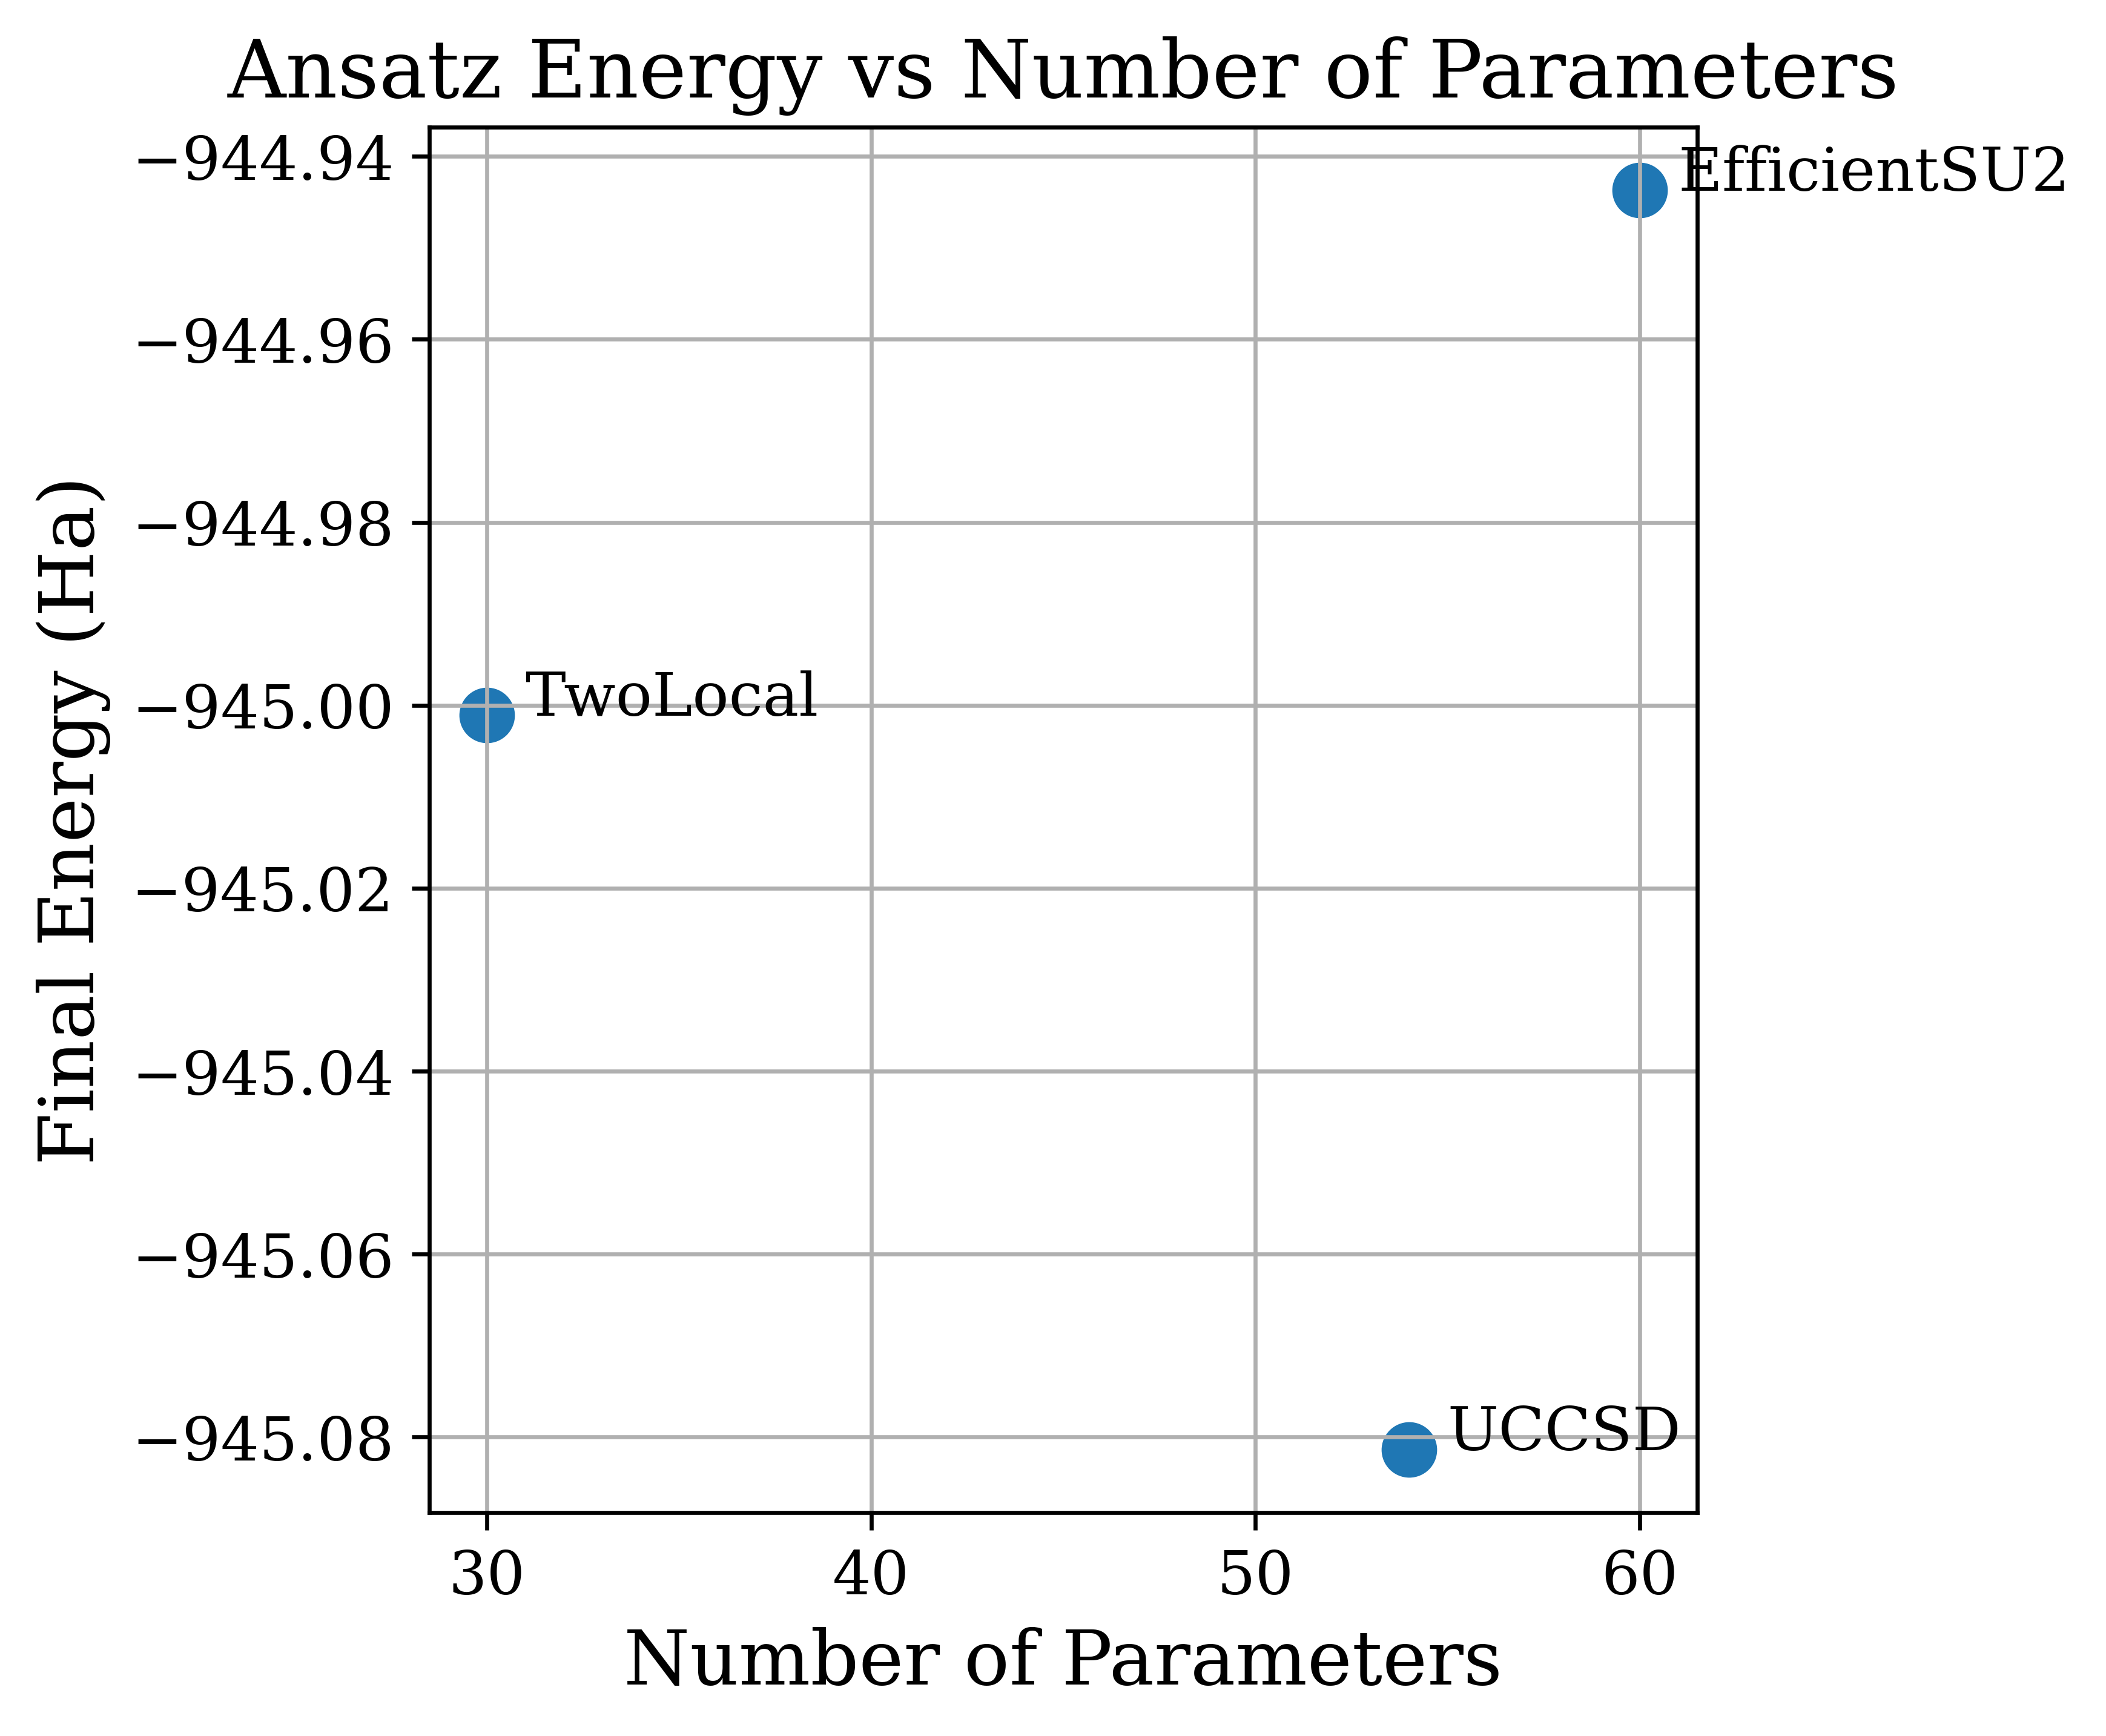

In [14]:
params = [summary[m]['Parameters'] for m in methods]
plt.figure(figsize=(6, 5))
plt.scatter(params, energies, color='tab:blue', s=100)
for i, method in enumerate(methods):
    plt.text(params[i] + 1, energies[i], method, fontsize=12)
plt.xlabel('Number of Parameters')
plt.ylabel('Final Energy (Ha)')
plt.title('Ansatz Energy vs Number of Parameters')
plt.grid(True)
plt.tight_layout()
#plt.savefig("vqe_energy_vs_parameters.png", dpi=600)
plt.show()


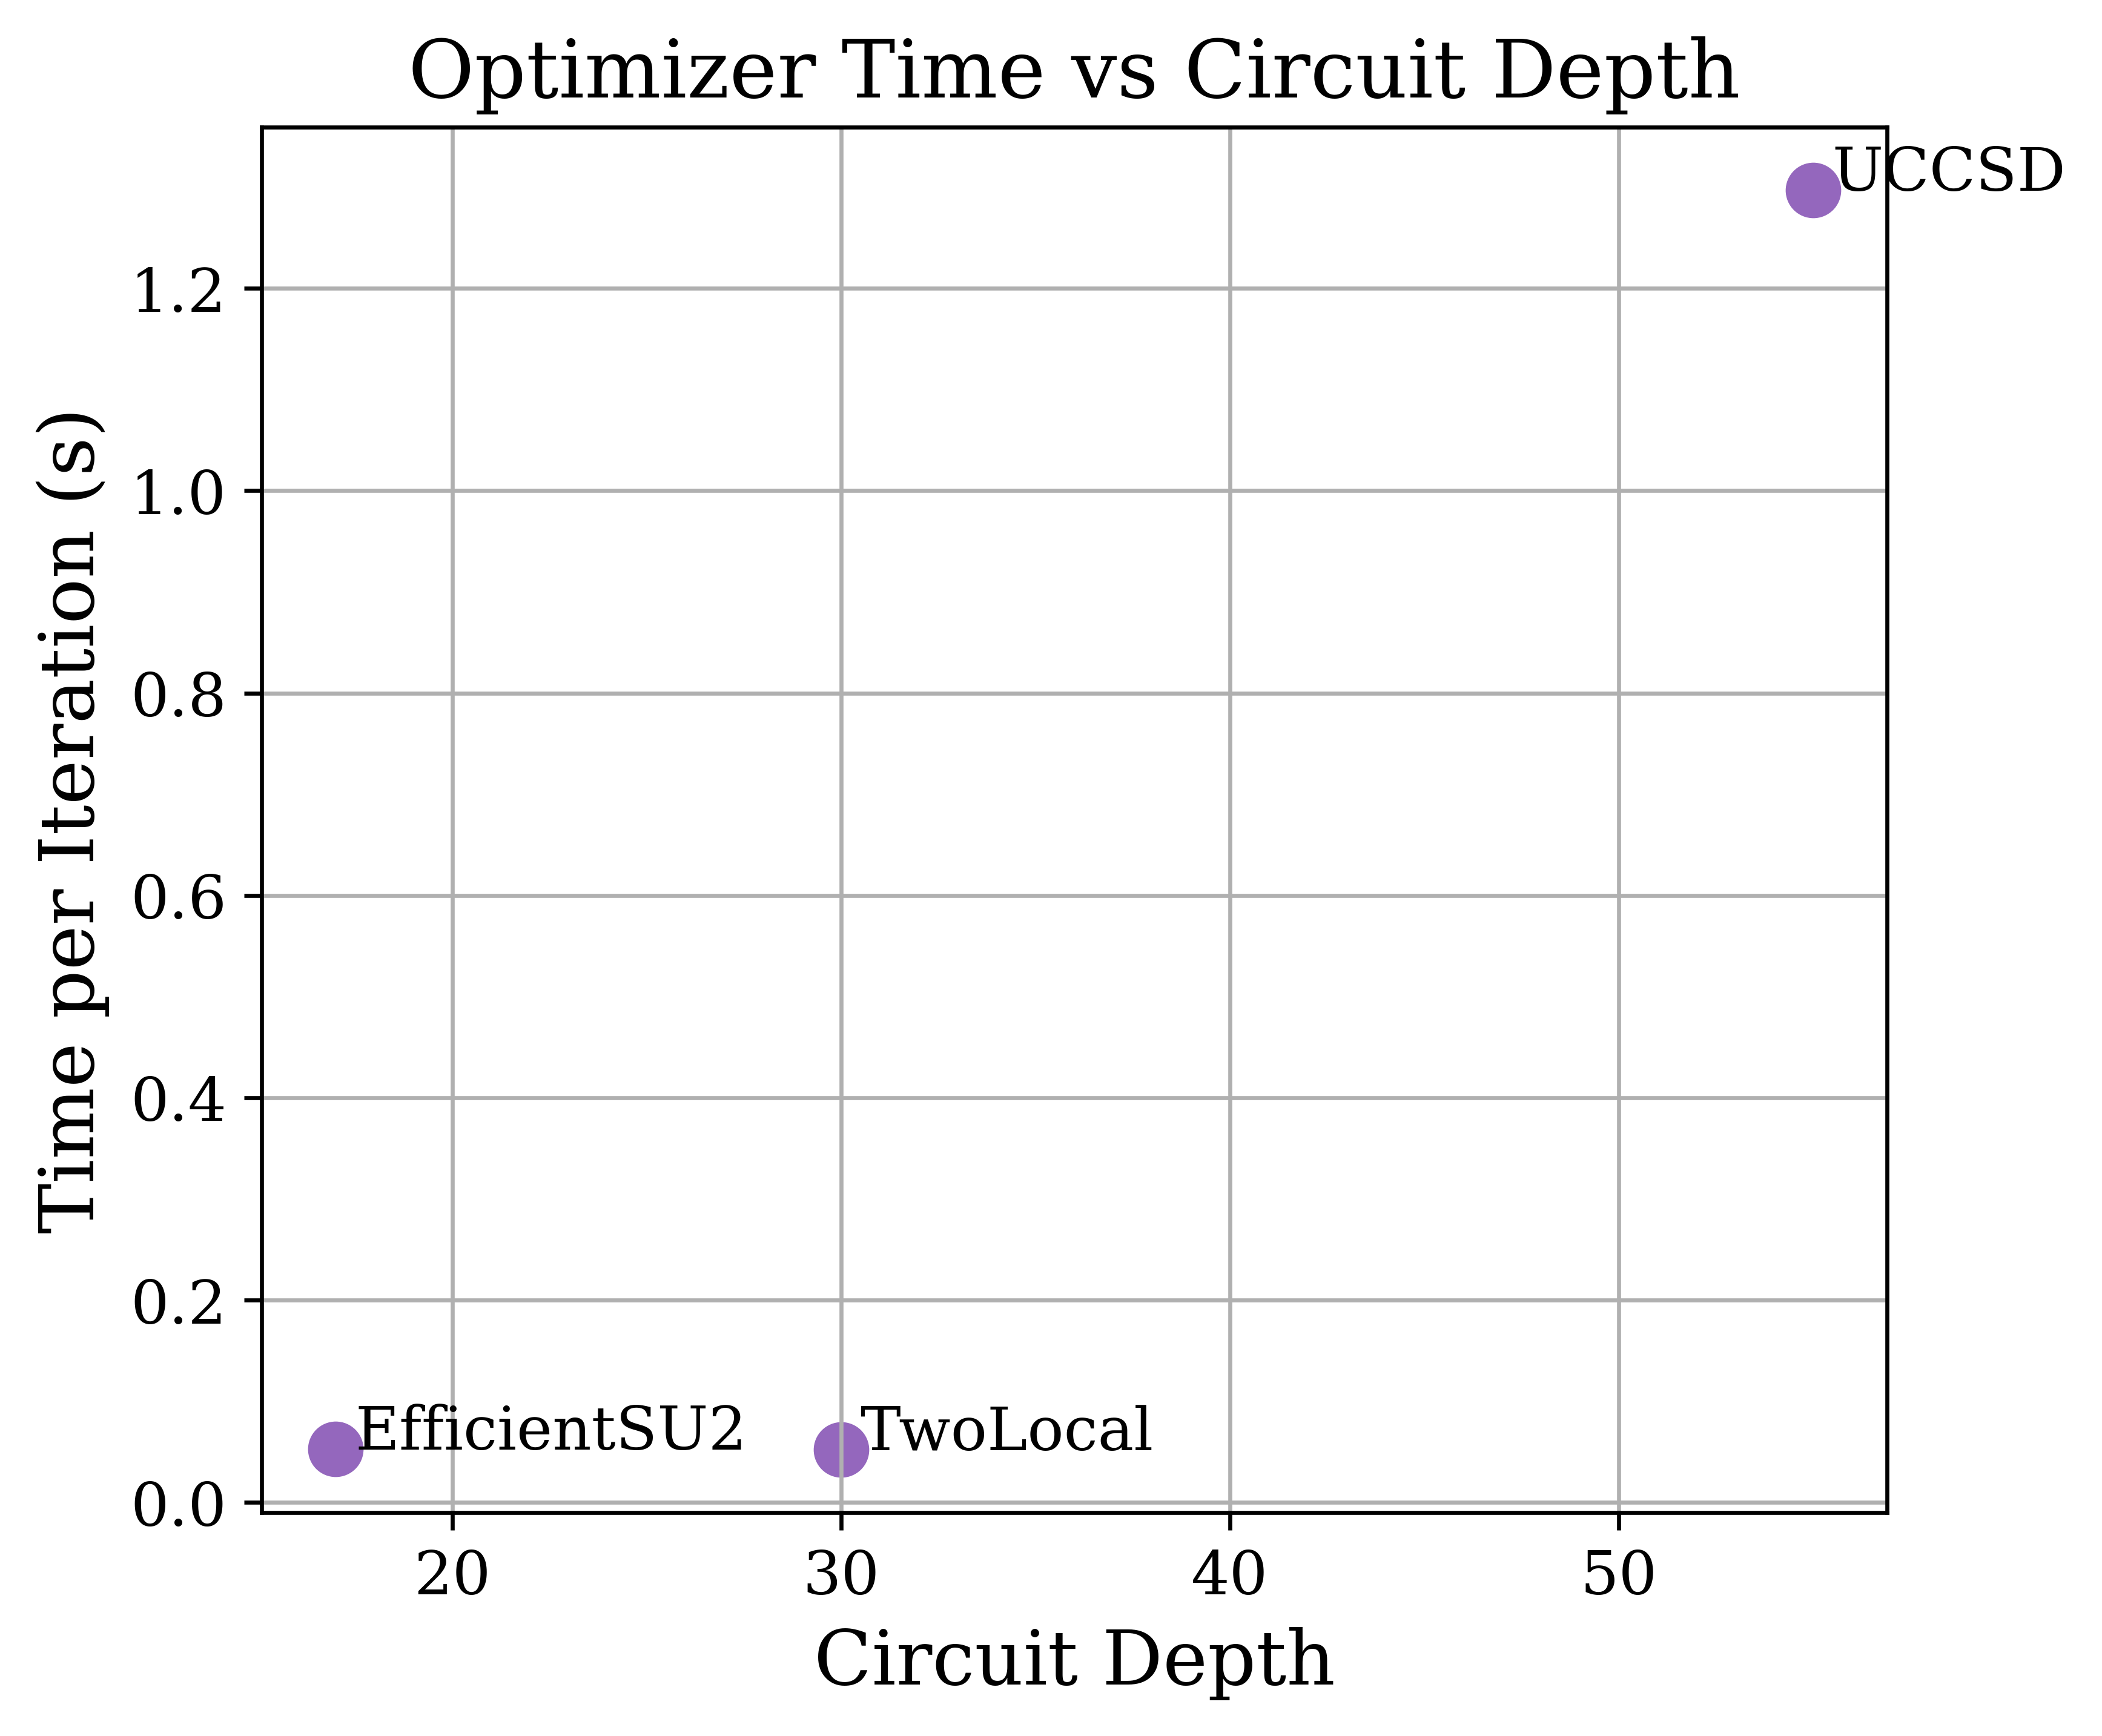

In [16]:
time_per_iter = [summary[m]['Time/Iter (s)'] for m in methods]
plt.figure(figsize=(6, 5))
plt.scatter(depths, time_per_iter, color='tab:purple', s=100)
for i, method in enumerate(methods):
    plt.text(depths[i] + 0.5, time_per_iter[i], method, fontsize=12)
plt.xlabel('Circuit Depth')
plt.ylabel('Time per Iteration (s)')
plt.title('Optimizer Time vs Circuit Depth')
plt.grid(True)
plt.tight_layout()
#plt.savefig("vqe_time_per_iter_vs_depth.png", dpi=600)
plt.show()

In [20]:
decomposed = ansatz.decompose()
ops = decomposed.count_ops()
summary[name].update({
    'Circuit': decomposed,
    'CNOT Gates': ops.get('cx', 0),
    'CZ Gates': ops.get('cz', 0),
    'Total Gates': sum(ops.values()),
    'Qubits': ansatz.num_qubits,
})

Distance: 1.5000 Å, Energy: -944.740594 Ha
Distance: 1.7647 Å, Energy: -944.923780 Ha
Distance: 2.0294 Å, Energy: -945.030364 Ha
Distance: 2.2941 Å, Energy: -945.074379 Ha
Distance: 2.4673 Å, Energy: -945.081387 Ha
Distance: 2.5588 Å, Energy: -945.080796 Ha
Distance: 2.8235 Å, Energy: -945.069785 Ha
Distance: 3.0882 Å, Energy: -945.052838 Ha
Distance: 3.3529 Å, Energy: -945.035114 Ha
Distance: 3.6176 Å, Energy: -945.018500 Ha
Distance: 3.8824 Å, Energy: -945.003545 Ha
Distance: 4.1471 Å, Energy: -944.990347 Ha
Distance: 4.4118 Å, Energy: -944.978824 Ha
Distance: 4.6765 Å, Energy: -944.968834 Ha
Distance: 4.9412 Å, Energy: -944.960217 Ha
Distance: 5.2059 Å, Energy: -944.952798 Ha
Distance: 5.4706 Å, Energy: -944.946379 Ha
Distance: 5.7353 Å, Energy: -944.940763 Ha
Distance: 6.0000 Å, Energy: -944.935775 Ha


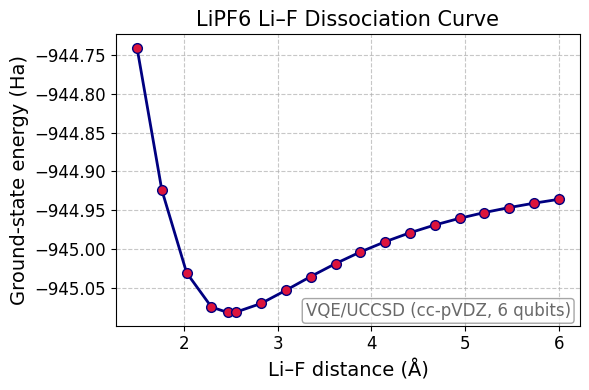

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# Li–F dissociation distances: include 2.4673 Å exactly
lf_distances = np.array(sorted(set(np.append(np.linspace(1.5, 6.0, 18), [2.4673]))))
vqe_energies = []
qubit_count = None
basis_set = 'cc-pVDZ'

for d in lf_distances:
    lipf6_geometry = (
        f"P 0.0000 0.0000 0.2077; "
        f"F 0.0000 1.1597 -1.1141; "
        f"F 0.0000 -1.1874 1.2692; "
        f"F -1.6097 0.0000 0.0830; "
        f"F 1.6097 0.0000 0.0830; "
        f"F 0.0000 -1.1597 -1.1141; "
        f"F 0.0000 1.1874 1.2692; "
        f"Li 0.0000 0.0000 {-d:6.4f}"
    )
    driver = PySCFDriver(atom=lipf6_geometry,
                         basis=basis_set,
                         charge=0,
                         spin=0,
                         unit=DistanceUnit.ANGSTROM)
    problem = driver.run()
    freeze_core     = list(range(0, 31))
    remove_orbitals = list(range(40, problem.num_spatial_orbitals))
    fc = FreezeCoreTransformer(freeze_core=False,
                               remove_orbitals=remove_orbitals+freeze_core)
    problem_red = fc.transform(problem)
    all_orbs     = set(range(problem.num_spatial_orbitals))
    frozen_orbs  = set(freeze_core)
    removed_orbs = set(remove_orbitals)
    kept_fc      = sorted(all_orbs - frozen_orbs - removed_orbs)
    active_orbs_reduced = [3, 4, 5]
    ast = ActiveSpaceTransformer(
        num_electrons=4,
        num_spatial_orbitals=3,
        active_orbitals=active_orbs_reduced
    )
    problem_act = ast.transform(problem_red)
    mapper = JordanWignerMapper()
    qubit_hamiltonian = mapper.map(problem_act.second_q_ops()[0])
    if qubit_count is None:
        qubit_count = qubit_hamiltonian.num_qubits
    init_state = HartreeFock(problem_act.num_spatial_orbitals,
                             problem_act.num_particles, mapper)
    ansatz = UCCSD(problem_act.num_spatial_orbitals,
                   problem_act.num_particles, mapper,
                   initial_state=init_state)
    vqe = VQE(estimator=Estimator(),
              ansatz=ansatz,
              optimizer=COBYLA(maxiter=10000))
    vqe.initial_point = [0.0] * ansatz.num_parameters
    gs_solver = GroundStateEigensolver(mapper, vqe)
    result = gs_solver.solve(problem_act)
    energy = result.total_energies[0].real
    vqe_energies.append(energy)
    print(f"Distance: {d:.4f} Å, Energy: {energy:.6f} Ha")

# Save bond distances and energies to a .dat file
with open("LiPF6_dissociation_energies.dat", "w") as f:
    f.write("# Li–F bond distance (Å)    Ground-state energy (Ha)\n")
    for d, e in zip(lf_distances, vqe_energies):
        f.write(f"{d:8.4f}\t{e: .8f}\n")


# Publication-quality plot
plt.figure(figsize=(6, 4))
plt.plot(lf_distances, vqe_energies, '-o', color='navy', markerfacecolor='crimson', markersize=7, linewidth=2)
plt.xlabel('Li–F distance (Å)', fontsize=14)
plt.ylabel('Ground-state energy (Ha)', fontsize=14)
plt.title('LiPF6 Li–F Dissociation Curve', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
# Add basis set and qubit count as annotation inside the plot
plt.annotate(f'VQE/UCCSD ({basis_set}, {qubit_count} qubits)', xy=(0.98, 0.02), xycoords='axes fraction', fontsize=12, color='dimgray', ha='right', va='bottom', bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', alpha=0.7))
plt.tight_layout()
plt.savefig('LiPF6_Li-F_dissociation_curve.png', dpi=600, bbox_inches='tight')
plt.show()

In [2]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM, ExcitedStatesEigensolver, EvaluationRule
from qiskit_algorithms import VQE, NumPyEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# ──────────────────────────────────────────────────────────────────────────────
# 1.  Geometry
# ──────────────────────────────────────────────────────────────────────────────
lipf6_geom = (
    "P  0.0000  0.0000  0.2077; "
    "F  0.0000  1.1597 -1.1141; "
    "F  0.0000 -1.1874  1.2692; "
    "F -1.6097  0.0000  0.0830; "
    "F  1.6097  0.0000  0.0830; "
    "F  0.0000 -1.1597 -1.1141; "
    "F  0.0000  1.1874  1.2692; "
    "Li 0.0000  0.0000 -2.4673"
)

driver = PySCFDriver(lipf6_geom,
                     basis="cc-pVDZ", #"631g*",
                     charge=0,
                     spin=0,
                     unit=DistanceUnit.ANGSTROM)
problem = driver.run()

# ──────────────────────────────────────────────────────────────────────────────
# 2.  Freeze‑core + trim virtuals
# ──────────────────────────────────────────────────────────────────────────────
freeze_core     = list(range(0, 31))            # freeze 20 lowest spatial MOs
remove_orbitals = list(range(40, problem.num_spatial_orbitals))

fc = FreezeCoreTransformer(freeze_core=False,
                           remove_orbitals=remove_orbitals + freeze_core)
problem_red = fc.transform(problem)

# Kept orbitals after freezing/removing
all_orbs  = set(range(problem.num_spatial_orbitals))
kept_fc   = sorted(all_orbs - set(freeze_core) - set(remove_orbitals))

# ──────────────────────────────────────────────────────────────────────────────
# 3.  Active space: 2 electrons in 2 spatial orbitals  (indices 6,7 in problem_red)
# ──────────────────────────────────────────────────────────────────────────────
active_orbs_reduced = [4, 5]  # change if you prefer a different window, use [2, 3, 4, 5, 6] for 5 orbitals active space
                              # [4,5] corresponds to the HOMO and LUMO in the reduced problem.
# Note: these indices are relative to the reduced problem after freeze+trim.
#       They map to the original problem as follows:
#       active_original = [kept_fc[i] for i in active_orbs_reduced]
#       e.g. if kept_fc = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
ast = ActiveSpaceTransformer(
    num_electrons=2,
    num_spatial_orbitals=2,
    active_orbitals=active_orbs_reduced
)
problem_act = ast.transform(problem_red)

# ──────────────────────────────────────────────────────────────────────────────
# 4.  Build qubit Hamiltonian
# ──────────────────────────────────────────────────────────────────────────────
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(problem_act.second_q_ops()[0])

# ──────────────────────────────────────────────────────────────────────────────
# 5.  VQE ground‑state calculation
# ──────────────────────────────────────────────────────────────────────────────
init_state = HartreeFock(problem_act.num_spatial_orbitals,
                         problem_act.num_particles, mapper)
ansatz = UCCSD(problem_act.num_spatial_orbitals,
               problem_act.num_particles, mapper,
               initial_state=init_state)

estimator=Estimator()
vqe = VQE(estimator=estimator,
          ansatz=ansatz,
          optimizer=COBYLA(maxiter=10000))
vqe.initial_point = [0.0] * ansatz.num_parameters

gs_solver = GroundStateEigensolver(mapper, vqe)
gs_result = gs_solver.solve(problem_act)

print("\n── VQE ground state ───────────────────────────")
print("Ground‑state energy :", gs_result.total_energies[0].real, "Ha")

# ──────────────────────────────────────────────────────────────────────────────
# 6.  QEOM excited‑state calculation
# ──────────────────────────────────────────────────────────────────────────────
qeom_solver = QEOM(gs_solver, estimator, "sd", EvaluationRule.ALL)
qeom_result = qeom_solver.solve(problem_act)

print("\n── QEOM spectrum (singles+doubles) ─────────────")
for idx, energy in enumerate(qeom_result.total_energies):
    label = "GS" if idx == 0 else f"ES {idx}"
    print(f"{label:<4}: {energy.real: .8f} Ha")

# ──────────────────────────────────────────────────────────────────────────────
# 7.  Classical exact solver for comparison (k=8 states)
# ──────────────────────────────────────────────────────────────────────────────
numpy_solver = NumPyEigensolver(k=4)
exact_es_solver = ExcitedStatesEigensolver(mapper, numpy_solver)
exact_result = exact_es_solver.solve(problem_act)

print("\n── NumPy exact spectrum (k=4) ─────────────────")
for idx, energy in enumerate(exact_result.total_energies):
    label = "GS" if idx == 0 else f"ES {idx}"
    print(f"{label:<4}: {energy.real: .8f} Ha")


── VQE ground state ───────────────────────────
Ground‑state energy : -945.0813870562871 Ha

── QEOM spectrum (singles+doubles) ─────────────
GS  : -945.08138706 Ha
ES 1: -944.59675679 Ha
ES 2: -944.59663828 Ha
ES 3: -943.76692029 Ha

── NumPy exact spectrum (k=4) ─────────────────
GS  : -945.09312277 Ha
ES 1: -945.09312277 Ha
ES 2: -945.08138706 Ha
ES 3: -944.88780543 Ha


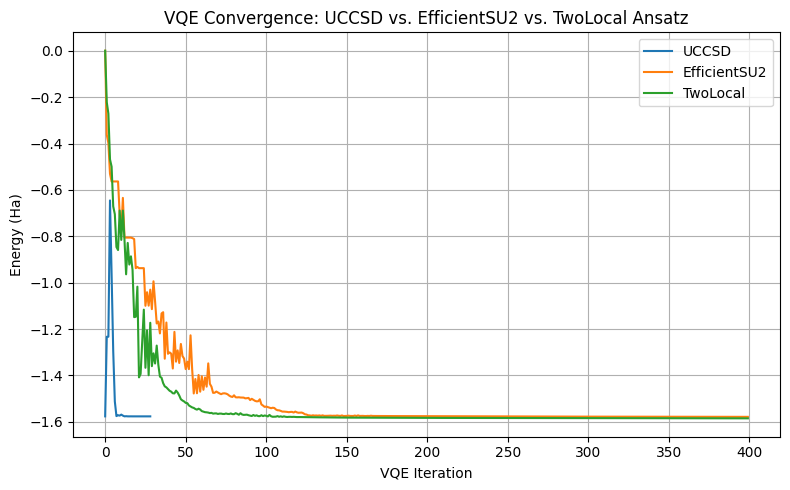

Final UCCSD energy: -945.081387 Ha
Final EfficientSU2 energy: -945.083442 Ha
Final TwoLocal energy: -945.089882 Ha


In [3]:
# VQE convergence tracking and ansatz comparison (UCCSD vs. EfficientSU2 vs. TwoLocal)
import matplotlib.pyplot as plt
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2, TwoLocal
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# Assume 'problem_act' is your active-space reduced problem from earlier
mapper = JordanWignerMapper()
init_state = HartreeFock(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper)

# UCCSD
energy_history_uccsd = []
def callback_uccsd(eval_count, params, energy, stddev):
    energy_history_uccsd.append(energy)
ansatz_uccsd = UCCSD(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper, initial_state=init_state)
vqe_uccsd = VQE(Estimator(), ansatz=ansatz_uccsd, optimizer=COBYLA(maxiter=200), callback=callback_uccsd, initial_point=[0.0]*ansatz_uccsd.num_parameters)
solver_uccsd = GroundStateEigensolver(mapper, vqe_uccsd)
result_uccsd = solver_uccsd.solve(problem_act)

# EfficientSU2
energy_history_he = []
def callback_he(eval_count, params, energy, stddev):
    energy_history_he.append(energy)
ansatz_he = EfficientSU2(problem_act.num_spatial_orbitals*2, reps=2)
vqe_he = VQE(Estimator(), ansatz=ansatz_he, optimizer=COBYLA(maxiter=400), callback=callback_he, initial_point=[0.0]*ansatz_he.num_parameters)
solver_he = GroundStateEigensolver(mapper, vqe_he)
result_he = solver_he.solve(problem_act)

# TwoLocal
energy_history_tl = []
def callback_tl(eval_count, params, energy, stddev):
    energy_history_tl.append(energy)
ansatz_tl = TwoLocal(num_qubits=problem_act.num_spatial_orbitals*2, rotation_blocks='ry', entanglement_blocks='cz', reps=2, entanglement='full')
vqe_tl = VQE(Estimator(), ansatz=ansatz_tl, optimizer=COBYLA(maxiter=400), callback=callback_tl, initial_point=[0.0]*ansatz_tl.num_parameters)
solver_tl = GroundStateEigensolver(mapper, vqe_tl)
result_tl = solver_tl.solve(problem_act)

# Plot optimizer energy history
plt.figure(figsize=(8,5))
plt.plot(energy_history_uccsd, label='UCCSD')
plt.plot(energy_history_he, label='EfficientSU2')
plt.plot(energy_history_tl, label='TwoLocal')
plt.xlabel('VQE Iteration')
plt.ylabel('Energy (Ha)')
plt.title('VQE Convergence: UCCSD vs. EfficientSU2 vs. TwoLocal Ansatz')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Final UCCSD energy: {result_uccsd.total_energies[0].real:.6f} Ha")
print(f"Final EfficientSU2 energy: {result_he.total_energies[0].real:.6f} Ha")
print(f"Final TwoLocal energy: {result_tl.total_energies[0].real:.6f} Ha")

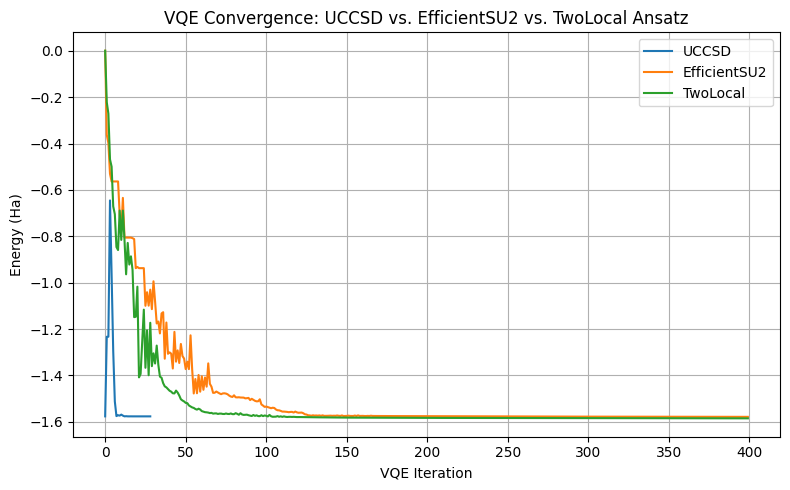

UCCSD:
  Energy: -945.0813870562871
  Iterations: 29
  Parameters: 3
  Depth: 4
  Time (s): 2.38
----------------------------------------
EfficientSU2:
  Energy: -945.083442485639
  Iterations: 400
  Parameters: 24
  Depth: 11
  Time (s): 6.34
----------------------------------------
TwoLocal:
  Energy: -945.0898824303835
  Iterations: 400
  Parameters: 12
  Depth: 12
  Time (s): 5.35
----------------------------------------


In [4]:
import matplotlib.pyplot as plt
import time
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import EfficientSU2, TwoLocal
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# Assume 'problem_act' is your active-space reduced problem from earlier
mapper = JordanWignerMapper()
init_state = HartreeFock(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper)

# Storage for reporting
summary = {}

### ---------- UCCSD ----------
energy_history_uccsd = []
def callback_uccsd(eval_count, params, energy, stddev):
    energy_history_uccsd.append(energy)

ansatz_uccsd = UCCSD(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper, initial_state=init_state)
optimizer_uccsd = COBYLA(maxiter=200)

start = time.time()
vqe_uccsd = VQE(Estimator(), ansatz=ansatz_uccsd, optimizer=optimizer_uccsd, callback=callback_uccsd, initial_point=[0.0]*ansatz_uccsd.num_parameters)
solver_uccsd = GroundStateEigensolver(mapper, vqe_uccsd)
result_uccsd = solver_uccsd.solve(problem_act)
end = time.time()

summary['UCCSD'] = {
    'Energy': result_uccsd.total_energies[0].real,
    'Iterations': len(energy_history_uccsd),
    'Parameters': ansatz_uccsd.num_parameters,
    'Depth': ansatz_uccsd.decompose().depth(),
    'Time (s)': round(end - start, 2)
}

### ---------- EfficientSU2 ----------
energy_history_he = []
def callback_he(eval_count, params, energy, stddev):
    energy_history_he.append(energy)

ansatz_he = EfficientSU2(problem_act.num_spatial_orbitals*2, reps=2)
optimizer_he = COBYLA(maxiter=400)

start = time.time()
vqe_he = VQE(Estimator(), ansatz=ansatz_he, optimizer=optimizer_he, callback=callback_he, initial_point=[0.0]*ansatz_he.num_parameters)
solver_he = GroundStateEigensolver(mapper, vqe_he)
result_he = solver_he.solve(problem_act)
end = time.time()

summary['EfficientSU2'] = {
    'Energy': result_he.total_energies[0].real,
    'Iterations': len(energy_history_he),
    'Parameters': ansatz_he.num_parameters,
    'Depth': ansatz_he.decompose().depth(),
    'Time (s)': round(end - start, 2)
}

### ---------- TwoLocal ----------
energy_history_tl = []
def callback_tl(eval_count, params, energy, stddev):
    energy_history_tl.append(energy)

ansatz_tl = TwoLocal(num_qubits=problem_act.num_spatial_orbitals*2, rotation_blocks='ry', entanglement_blocks='cz', reps=2, entanglement='full')
optimizer_tl = COBYLA(maxiter=400)

start = time.time()
vqe_tl = VQE(Estimator(), ansatz=ansatz_tl, optimizer=optimizer_tl, callback=callback_tl, initial_point=[0.0]*ansatz_tl.num_parameters)
solver_tl = GroundStateEigensolver(mapper, vqe_tl)
result_tl = solver_tl.solve(problem_act)
end = time.time()

summary['TwoLocal'] = {
    'Energy': result_tl.total_energies[0].real,
    'Iterations': len(energy_history_tl),
    'Parameters': ansatz_tl.num_parameters,
    'Depth': ansatz_tl.decompose().depth(),
    'Time (s)': round(end - start, 2)
}

### ---------- Plot ----------
plt.figure(figsize=(8, 5))
plt.plot(energy_history_uccsd, label='UCCSD')
plt.plot(energy_history_he, label='EfficientSU2')
plt.plot(energy_history_tl, label='TwoLocal')
plt.xlabel('VQE Iteration')
plt.ylabel('Energy (Ha)')
plt.title('VQE Convergence: UCCSD vs. EfficientSU2 vs. TwoLocal Ansatz')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### ---------- Print Summary ----------
for method, stats in summary.items():
    print(f"{method}:")
    for key, value in stats.items():
        print(f"  {key}: {value}")
    print("-" * 40)


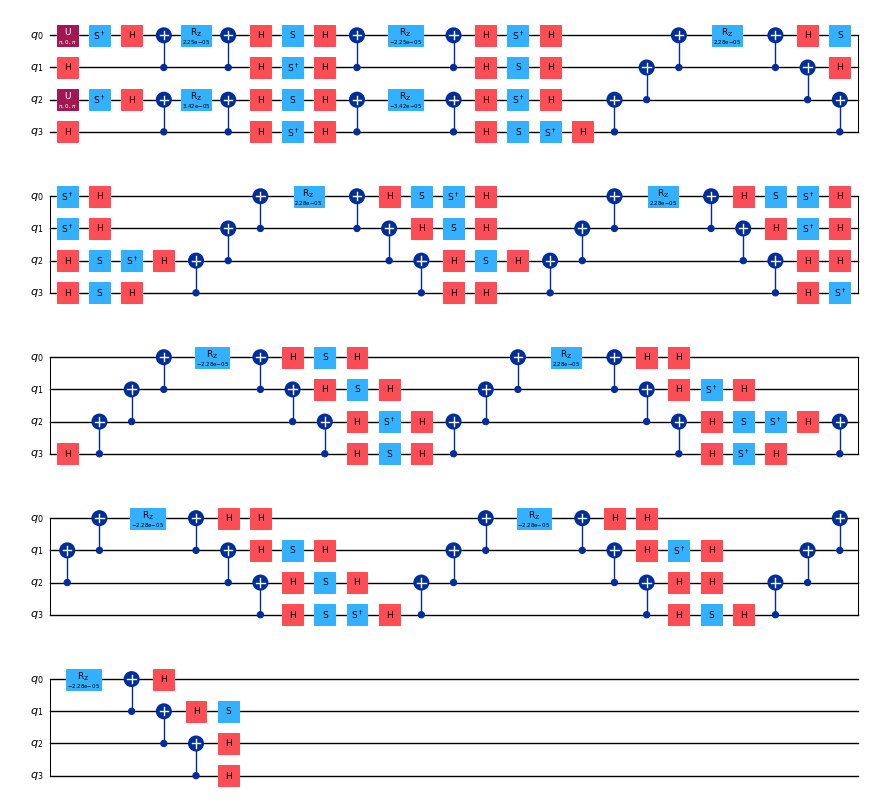

In [82]:
# Optional: visualize ansatz
ansatz.assign_parameters(result.raw_result.optimal_point).decompose(reps=3).draw("mpl", style="iqp", scale=0.5)

In [57]:
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM, ExcitedStatesEigensolver
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.units import DistanceUnit
from qiskit_algorithms import NumPyEigensolver, VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit.primitives import Estimator
from qiskit_nature.second_q.algorithms import EvaluationRule

# === Step 1: Geometry and driver ===
lipf6_geometry = (
    "P 0.0000 0.0000 0.2077; "
    "F 0.0000 1.1597 -1.1141; "
    "F 0.0000 -1.1874 1.2692; "
    "F -1.6097 0.0000 0.0830; "
    "F 1.6097 0.0000 0.0830; "
    "F 0.0000 -1.1597 -1.1141; "
    "F 0.0000 1.1874 1.2692; "
    "Li 0.0000 0.0000 -2.4673"
)

# === Driver ===
driver = PySCFDriver(atom=lipf6_geometry, basis="631g", charge=0, spin=0, unit=DistanceUnit.ANGSTROM)
problem = driver.run()

# === Original HF problem info ===
print("\n── Original HF problem ─────────────────────────")
print("Spatial orbitals :", problem.num_spatial_orbitals)
print("Spin  orbitals   :", problem.num_spin_orbitals)
na, nb = problem.num_particles
print(f"Electrons        : {na+nb} ({na} α, {nb} β)\n")

# === FreezeCoreTransformer ===
frozen_core = list(range(0, 32))
removed = list(range(38, problem.num_spatial_orbitals))
fc = FreezeCoreTransformer(freeze_core=False, remove_orbitals=removed+frozen_core)
problem_red = fc.transform(problem)

# Show info after FreezeCoreTransformer
all_orbs = set(range(problem.num_spatial_orbitals))
frozen_orbs = set(frozen_core)
removed_orbs = set(removed)
kept_fc = sorted(all_orbs - frozen_orbs - removed_orbs)

print("── After FreezeCoreTransformer ────────────────")
print("Frozen orbitals   :", sorted(frozen))
print("Removed virtuals  :", sorted(removed))
print("Kept orbitals     :", kept_fc)
print("Spatial orbitals  :", problem_red.num_spatial_orbitals, "\n")
na, nb = problem_red.num_particles
print(f"Electrons        : {na+nb} ({na} α, {nb} β)\n")

# === Active space ===
#active_indices_reduced = [0,1,2,3,4,5]  # relative to kept orbitals
#active_orbitals_original = [kept_fc[i] for i in active_indices_reduced]
active_indices_reduced = [kept_fc.index(i) for i in range(35, 37)]  # 33 to 39 inclusive
active_orbitals_original = [kept_fc[i] for i in active_indices_reduced]

ast = ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=2, active_orbitals=active_indices_reduced)
problem_active = ast.transform(problem_red)

print("── Active space ───────────────────────────────")
print("Active orbitals (re‑indexed) :", active_indices_reduced)
print("Active orbitals (original HF):", active_orbitals_original)
print("Spatial orbitals              :", problem_active.num_spatial_orbitals)
na, nb = problem_active.num_particles
print(f"Electrons                     : {na+nb} ({na} α, {nb} β)\n")

# === NumPy exact eigensolver ===
mapper = JordanWignerMapper()
numpy_solver = NumPyEigensolver(k=8)
numpy_excited_solver = ExcitedStatesEigensolver(mapper, numpy_solver)
numpy_results = numpy_excited_solver.solve(problem_active)

# === VQE + QEOM ===
estimator = Estimator()
ansatz = UCCSD(
    problem_active.num_spatial_orbitals,
    problem_active.num_particles,
    mapper,
    initial_state=HartreeFock(
        problem_active.num_spatial_orbitals,
        problem_active.num_particles,
        mapper,
    ),
)
vqe_solver = VQE(estimator, ansatz, SLSQP())
vqe_solver.initial_point = [0.0] * ansatz.num_parameters

gse = GroundStateEigensolver(mapper, vqe_solver)
qeom_solver = QEOM(gse, estimator, "sd", EvaluationRule.ALL)
qeom_results = qeom_solver.solve(problem_active)

# === Output results ===
print("\n=== NumPy (Exact) Excited State Energies of LiPF6 ===")
for i, e in enumerate(numpy_results.total_energies):
    print(f"State {i}: {e.real:.6f} Hartree")

print("\n=== VQE + qEOM Excited State Energies of LiPF6 ===")
gs_energy = qeom_results.total_energies[0].real
for i, e in enumerate(qeom_results.total_energies):
    label = "Ground" if i == 0 else f"Excited {i}"
    delta_e = e.real - gs_energy if i > 0 else 0
    print(f"{label} State: {e.real:.6f} Hartree", end="")
    if i > 0:
        print(f"   ΔE = {delta_e:.6f} Hartree ≈ {delta_e * 27.2114:.2f} eV")
    else:
        print()

bandgap = qeom_results.computed_energies[1] - qeom_results.computed_energies[0]
print("\n=== HOMO and LUMO gap of LiPF6 ===")
print(f" ΔE_gap = {bandgap:.6f} Hartree ≈ {bandgap * 27.2114:.2f} eV")


── Original HF problem ─────────────────────────
Spatial orbitals : 76
Spin  orbitals   : 152
Electrons        : 72 (36 α, 36 β)

── After FreezeCoreTransformer ────────────────
Frozen orbitals   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Removed virtuals  : [38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75]
Kept orbitals     : [32, 33, 34, 35, 36, 37]
Spatial orbitals  : 6 

Electrons        : 8 (4 α, 4 β)

── Active space ───────────────────────────────
Active orbitals (re‑indexed) : [3, 4]
Active orbitals (original HF): [35, 36]
Spatial orbitals              : 2
Electrons                     : 2 (1 α, 1 β)


=== NumPy (Exact) Excited State Energies of LiPF6 ===
State 0: -944.762398 Hartree
State 1: -944.762398 Hartree
State 2: -944.752161 Hartree
State 3: -944.533103 Hartree
State 4: -944.244386 Hartree
State 5: -944.244386 Hartree


In [49]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper

# Step 1: Geometry for LiPF6
lipf6_geometry = (
    "P 0.0000 0.0000 0.2077; "
    "F 0.0000 1.1597 -1.1141; "
    "F 0.0000 -1.1874 1.2692; "
    "F -1.6097 0.0000 0.0830; "
    "F 1.6097 0.0000 0.0830; "
    "F 0.0000 -1.1597 -1.1141; "
    "F 0.0000 1.1874 1.2692; "
    "Li 0.0000 0.0000 -2.4673"
)

driver = PySCFDriver(
    atom=lipf6_geometry,
    basis="631g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM
)
es_problem = driver.run()

# Print original HF problem
print("── Original HF problem ─────────────────────────")
print("Spatial orbitals :", es_problem.num_spatial_orbitals)
print("Spin  orbitals   :", es_problem.num_spin_orbitals)
n_alpha, n_beta = es_problem.num_particles
print(f"Electrons        : {n_alpha + n_beta} ({n_alpha} α, {n_beta} β)")
print("Qubits needed    :", 2 * es_problem.num_spatial_orbitals)

# === Step 2: Apply FreezeCoreTransformer ===
removed_orbitals = list(range(37, es_problem.num_spatial_orbitals))  # virtuals above 36
freeze_transformer = FreezeCoreTransformer(
    freeze_core=True,
    remove_orbitals=removed_orbitals
)
es_problem_reduced = freeze_transformer.transform(es_problem)

# Compute frozen/removed/kept orbital indices
all_orbitals = set(range(es_problem.num_spatial_orbitals))
frozen_orbitals = set(freeze_transformer.frozen_orbitals)
removed_virtuals = set(removed_orbitals)
kept_orbitals = sorted(list(all_orbitals - frozen_orbitals - removed_virtuals))

# Print info after freezing
print("\n── After FreezeCoreTransformer ────────────────")
print("Frozen orbitals   :", sorted(freeze_transformer.frozen_orbitals))
print("Removed virtuals  :", removed_orbitals)
print("Kept orbitals     :", kept_orbitals)
print("Spatial orbitals  :", es_problem_reduced.num_spatial_orbitals)

na, nb = es_problem_reduced.num_particles
print(f"\nElectrons        : {na + nb} ({na} α, {nb} β)")

── Original HF problem ─────────────────────────
Spatial orbitals : 76
Spin  orbitals   : 152
Electrons        : 72 (36 α, 36 β)
Qubits needed    : 152


AttributeError: 'FreezeCoreTransformer' object has no attribute 'frozen_orbitals'

In [50]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper

# === Step 1: Molecule ===
lipf6_geometry = (
    "P 0.0000 0.0000 0.2077; "
    "F 0.0000 1.1597 -1.1141; "
    "F 0.0000 -1.1874 1.2692; "
    "F -1.6097 0.0000 0.0830; "
    "F 1.6097 0.0000 0.0830; "
    "F 0.0000 -1.1597 -1.1141; "
    "F 0.0000 1.1874 1.2692; "
    "Li 0.0000 0.0000 -2.4673"
)

driver = PySCFDriver(atom=lipf6_geometry, basis="631g", charge=0, spin=0, unit=DistanceUnit.ANGSTROM)
problem = driver.run()

print("── Original HF problem ─────────────────────────")
print("Spatial orbitals :", problem.num_spatial_orbitals)
print("Spin  orbitals   :", problem.num_spin_orbitals)
na, nb = problem.num_particles
print(f"Electrons        : {na + nb} ({na} α, {nb} β)")
print("Qubits needed    :", 2 * problem.num_spatial_orbitals)

# === Step 2: Apply FreezeCoreTransformer ===
remove_orbitals = list(range(37, problem.num_spatial_orbitals))
fc_transformer = FreezeCoreTransformer(freeze_core=True, remove_orbitals=remove_orbitals)
problem_red = fc_transformer.transform(problem)

# === Step 3: Recover which orbitals were frozen and removed ===
# Total orbitals before transformation
total_orbitals = problem.num_spatial_orbitals
# Orbitals after transformation
remaining_orbitals = problem_red.num_spatial_orbitals

# We know how many electrons were removed → infer frozen orbitals:
n_removed_electrons = (na + nb) - sum(problem_red.num_particles)
n_frozen_orbitals = n_removed_electrons // 2
frozen_orbitals = list(range(n_frozen_orbitals))

# Removed virtuals were given explicitly
removed_virtuals = remove_orbitals

# Remaining orbitals are the ones not frozen or removed
all_indices = set(range(total_orbitals))
kept_orbitals = sorted(all_indices - set(frozen_orbitals) - set(removed_virtuals))

# === Step 4: Print the info ===
print("\n── After FreezeCoreTransformer ────────────────")
print("Frozen orbitals   :", frozen_orbitals)
print("Removed virtuals  :", removed_virtuals)
print("Kept orbitals     :", kept_orbitals)
print("Spatial orbitals  :", problem_red.num_spatial_orbitals)
na_red, nb_red = problem_red.num_particles
print(f"\nElectrons         : {na_red + nb_red} ({na_red} α, {nb_red} β)")


── Original HF problem ─────────────────────────
Spatial orbitals : 76
Spin  orbitals   : 152
Electrons        : 72 (36 α, 36 β)
Qubits needed    : 152

── After FreezeCoreTransformer ────────────────
Frozen orbitals   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Removed virtuals  : [37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75]
Kept orbitals     : [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]
Spatial orbitals  : 25

Electrons         : 48 (24 α, 24 β)


In [53]:
# Freeze occupied orbitals 0 through 31
frozen_orbitals = list(range(0, 32))

# Remove high virtuals starting from orbital 37
removed_virtuals = list(range(37, es_problem.num_spatial_orbitals))

fc_transformer = FreezeCoreTransformer(
    freeze_core=False,
#    freeze_core=frozen_orbitals,
    remove_orbitals=removed_virtuals
)
problem_red = fc_transformer.transform(es_problem)

# Then print info as before
n_removed_electrons = (n_alpha + n_beta) - sum(problem_red.num_particles)
n_frozen_orbitals = n_removed_electrons // 2
print("Frozen orbitals :", frozen_orbitals)
print("Removed virtuals:", removed_virtuals)
print("Remaining orbitals:", problem_red.num_spatial_orbitals)


Frozen orbitals : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
Removed virtuals: [37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75]
Remaining orbitals: 37


In [54]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper

# Step 1: Geometry
lipf6_geometry = (
    "P 0.0000 0.0000 0.2077; "
    "F 0.0000 1.1597 -1.1141; "
    "F 0.0000 -1.1874 1.2692; "
    "F -1.6097 0.0000 0.0830; "
    "F 1.6097 0.0000 0.0830; "
    "F 0.0000 -1.1597 -1.1141; "
    "F 0.0000 1.1874 1.2692; "
    "Li 0.0000 0.0000 -2.4673"
)

# Step 2: Run HF calculation
driver = PySCFDriver(atom=lipf6_geometry, basis="631g", charge=0, spin=0, unit=DistanceUnit.ANGSTROM)
es_problem = driver.run()

# Step 3: Print original system info
print("── Original HF problem ─────────────────────────")
print("Spatial orbitals :", es_problem.num_spatial_orbitals)
print("Spin orbitals    :", es_problem.num_spin_orbitals)
n_alpha, n_beta = es_problem.num_particles
print("Electrons        :", n_alpha + n_beta, f"({n_alpha} α, {n_beta} β)")
print("Qubits needed    :", es_problem.num_spin_orbitals)

# Step 4: Freeze custom occupied orbitals (0–31) and remove virtuals (37+)
frozen_orbitals = list(range(0, 32))  # Freeze extra occupied orbitals beyond default core
removed_virtuals = list(range(37, es_problem.num_spatial_orbitals))

# Step 5: Custom freezing using freeze_core=False
transformer = FreezeCoreTransformer(
    freeze_core=False,                       # disable default core logic
    remove_orbitals=removed_virtuals + frozen_orbitals  # remove both virtuals and extra occupieds
)
es_problem_reduced = transformer.transform(es_problem)

# Step 6: Print post-transform info
total_orbitals = set(range(es_problem.num_spatial_orbitals))
removed = set(frozen_orbitals + removed_virtuals)
kept = sorted(total_orbitals - removed)

print("\n── After FreezeCoreTransformer ────────────────")
print("Frozen orbitals   :", frozen_orbitals)
print("Removed virtuals  :", removed_virtuals)
print("Kept orbitals     :", kept)
print("Spatial orbitals  :", es_problem_reduced.num_spatial_orbitals)
n_alpha_r, n_beta_r = es_problem_reduced.num_particles
print("Electrons         :", n_alpha_r + n_beta_r, f"({n_alpha_r} α, {n_beta_r} β)")


── Original HF problem ─────────────────────────
Spatial orbitals : 76
Spin orbitals    : 152
Electrons        : 72 (36 α, 36 β)
Qubits needed    : 152

── After FreezeCoreTransformer ────────────────
Frozen orbitals   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
Removed virtuals  : [37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75]
Kept orbitals     : [32, 33, 34, 35, 36]
Spatial orbitals  : 5
Electrons         : 8 (4 α, 4 β)
